In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch12. 데이터 시각화</font>

In [2]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정(Win/MacOS)
# plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family='AppleGothic') # Mac
# plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

# 2절. Seaborn
- matplotlib기반으로 만든 고수준 그래픽 라이브러리
    * 공식 API 사이트 : https://seaborn.pydata.org/api.html
- Seaborn으로 그래프를 그리기 위해서 다음의 단계를 따릅니다.
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수를 이용해서 그래프 그리기(관계형-수치형, 범주형, 쌍관계, 밀도, 회귀, 다중그래프...)
        - 그래프 커스토마이징
    4) 그래프 출력(show), 저장(savefig)

## 2.1 데이터 준비하기
- iris, titanic

In [5]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
titanic = sns.load_dataset('titanic')
# Survived : 생존 여부 (0 = 사망, 1 = 생존)
# Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
# Sex : 성별
# Age : 나이
# SibSp : 함께 탑승한 자녀 / 배우자 의 수
# Parch : 함께 탑승한 부모님 / 아이들 의 수
# Ticket : 티켓 번호
# Fare : 탑승 요금
# Cabin : 수하물 번호
# Boat : 탈출한 보트가 있다면 boat 번호
# Embarked : 탑승 선착장 (C = Cherbourg, Q = Queenstown, S = Southampton)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 2.2 미적 속성 설정(style, context, palette, figsize...)
### 1) 그래프 스타일 지정
- 미적 속성 설정 후, 한글설정을 다시 실행
    * plt.rc('font', family='Malgun Gothic') # 윈도우즈
    * plt.rc('axes', unicode_minus=False)
    
    * 범례(교안20p) : https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

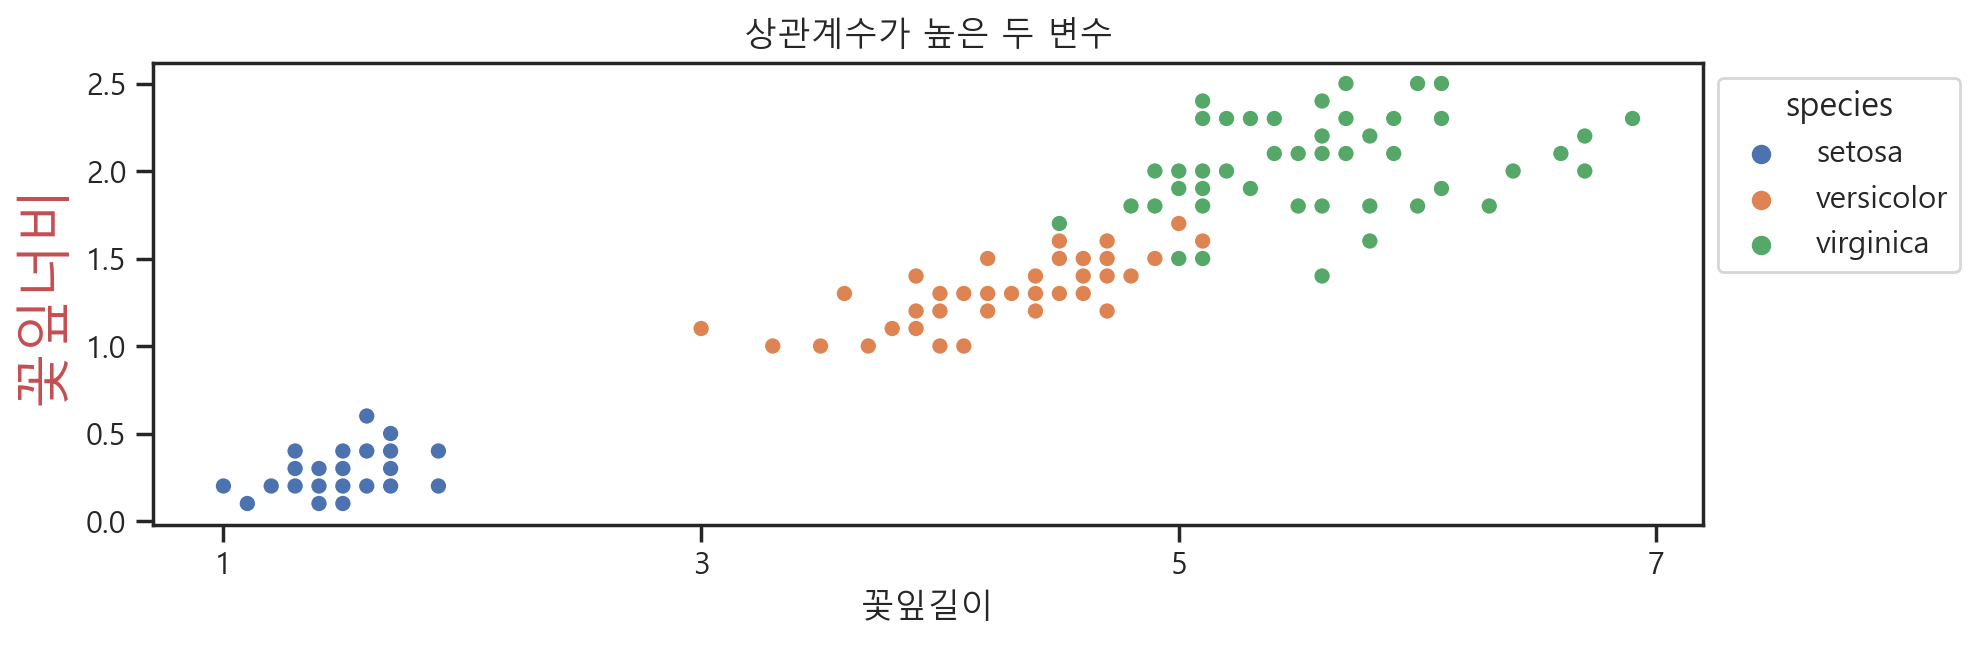

In [30]:
plt.rcParams['figure.figsize'] = (10,3)
sns.set(style='ticks') # darkgrid, whitegrid, dark, white, ticks
# sns.set_style('whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
# plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관계수가 높은 두 변수',
      xlabel='꽃잎길이',
      xticks=[1, 3, 5, 7])
ax.set_ylabel('꽃잎너비', fontsize=20, color='r')
plt.show()

### 2) 컨텍스트 지정(배율)

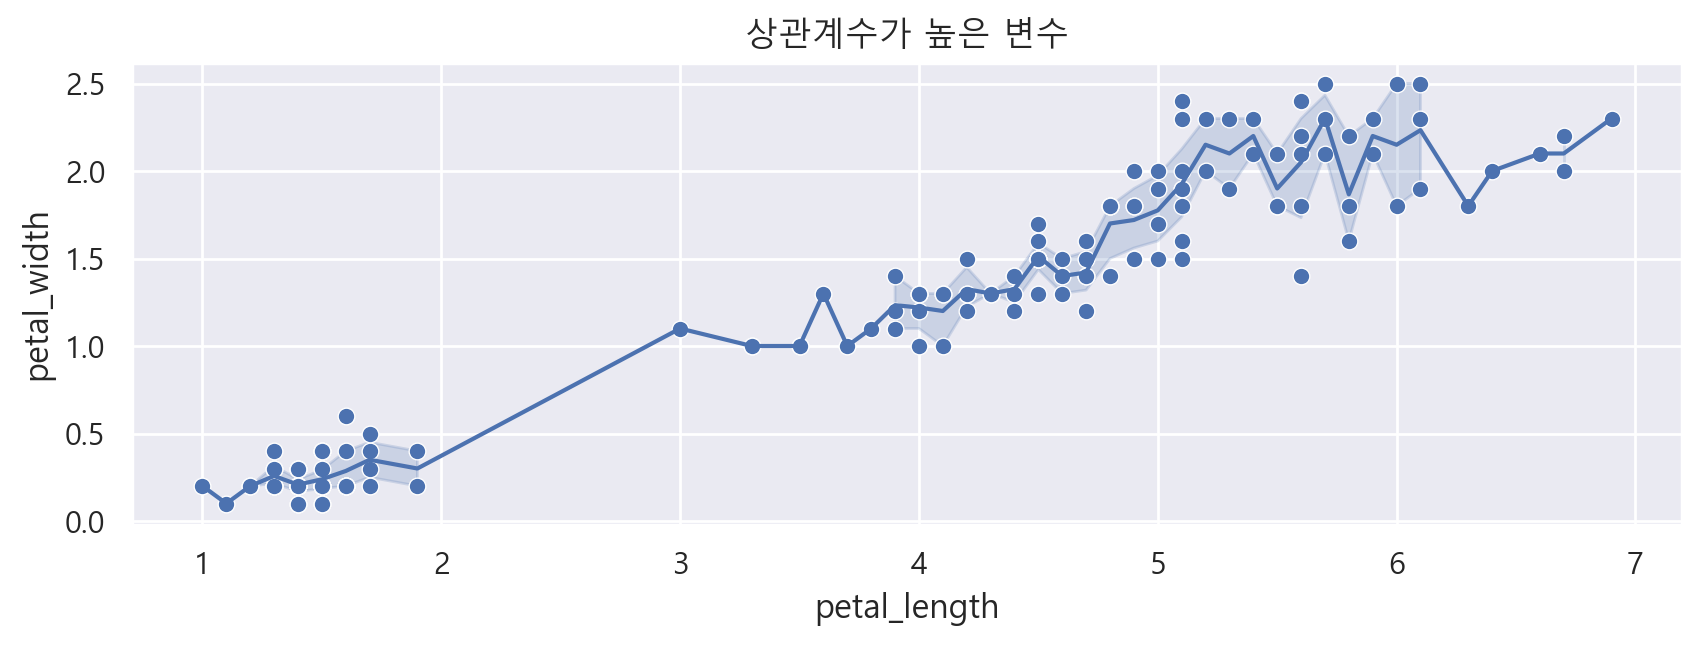

In [36]:
sns.set(context='notebook') # 기본값notebook(1.0), paper(0.8), talk(1.3), poster(1.8)
# sns.set_context('notebook')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.lineplot(data=iris, x='petal_length', y='petal_width')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')
plt.title('상관계수가 높은 변수')
plt.show()

### 3) 컬러 팔레트

- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette (교안54p)
- https://matplotlib.org/tutorials/colors/colormaps.html (교안54p)
- https://seaborn.pydata.org/tutorial/color_palettes.html (교안54p)

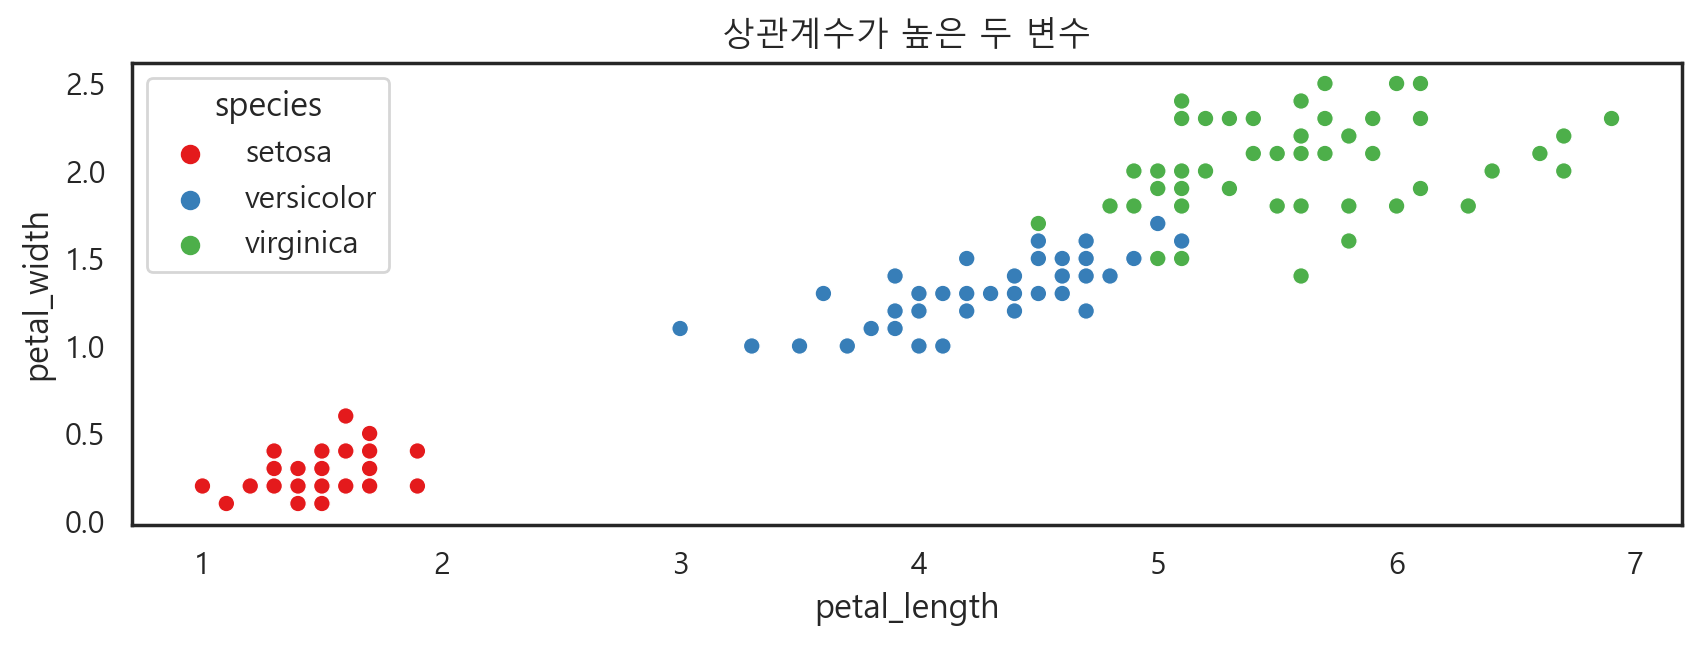

In [38]:
sns.set(palette='Pastel1', style='white', context='notebook') # 기본 미적 속성 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set1')
ax.set(title='상관계수가 높은 두 변수')
plt.show()

In [2]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
# 미적 속성 셋팅
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3)})
# 한글 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안 보이게
# warnings.filterwarnings(action='default') # 기본 경고 메세지 다 보이게

In [3]:
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')

## 2.3 Seaborn 함수로 그래프 그리기
### 1) 관계형 그래프
    - scatterplot, lineplot, relplot(서브플롯 제공)

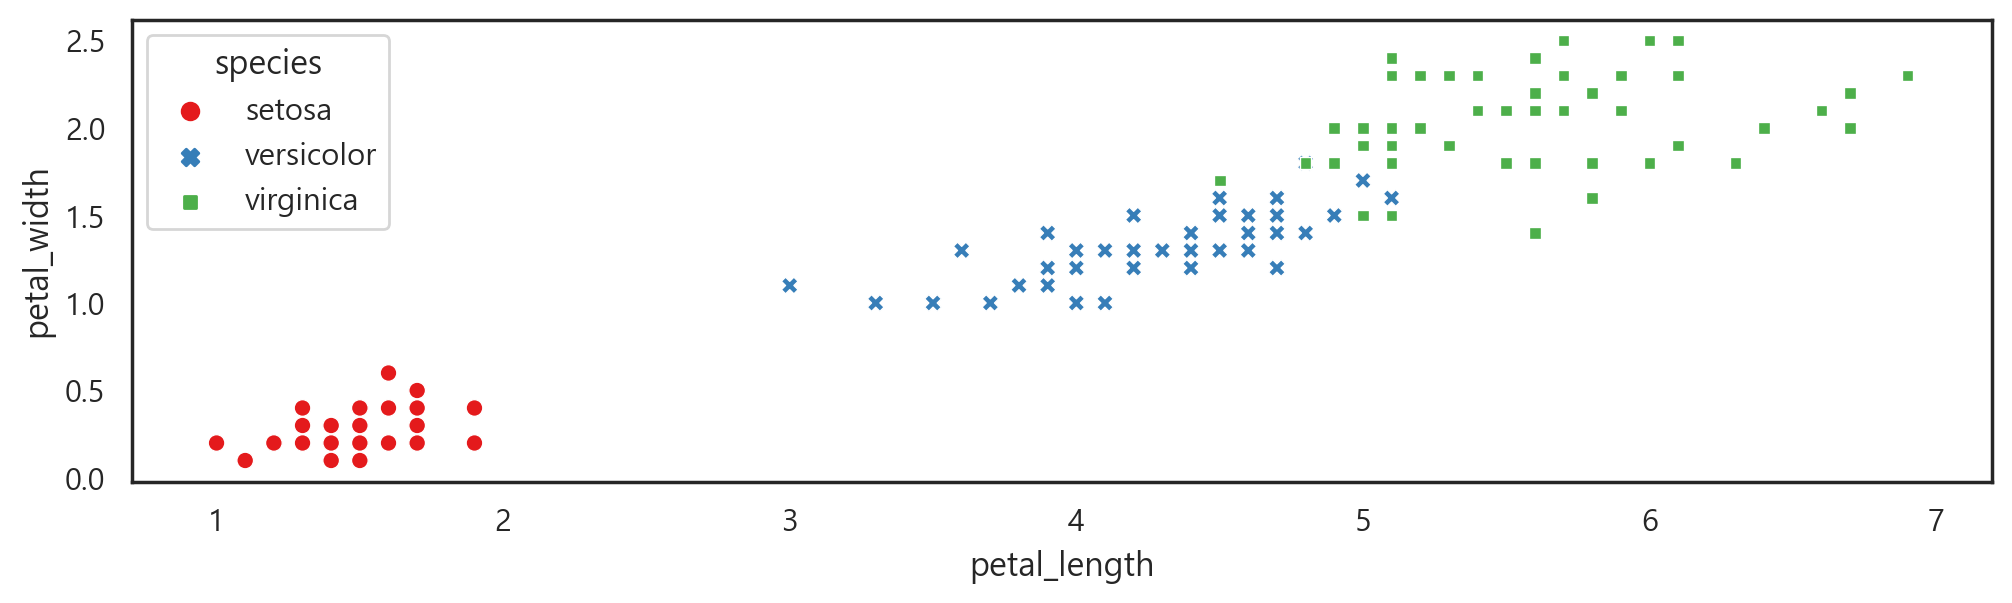

In [43]:
# 종별 다른 색상과 다른 스타일의 scatterplt
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', palette='Set1',
               style='species')
# sns.scatterplot(x=iris.petal_length, y=iris.petal_width, hue=iris.species, palette='Set1',
#                style=iris.species)
plt.show()

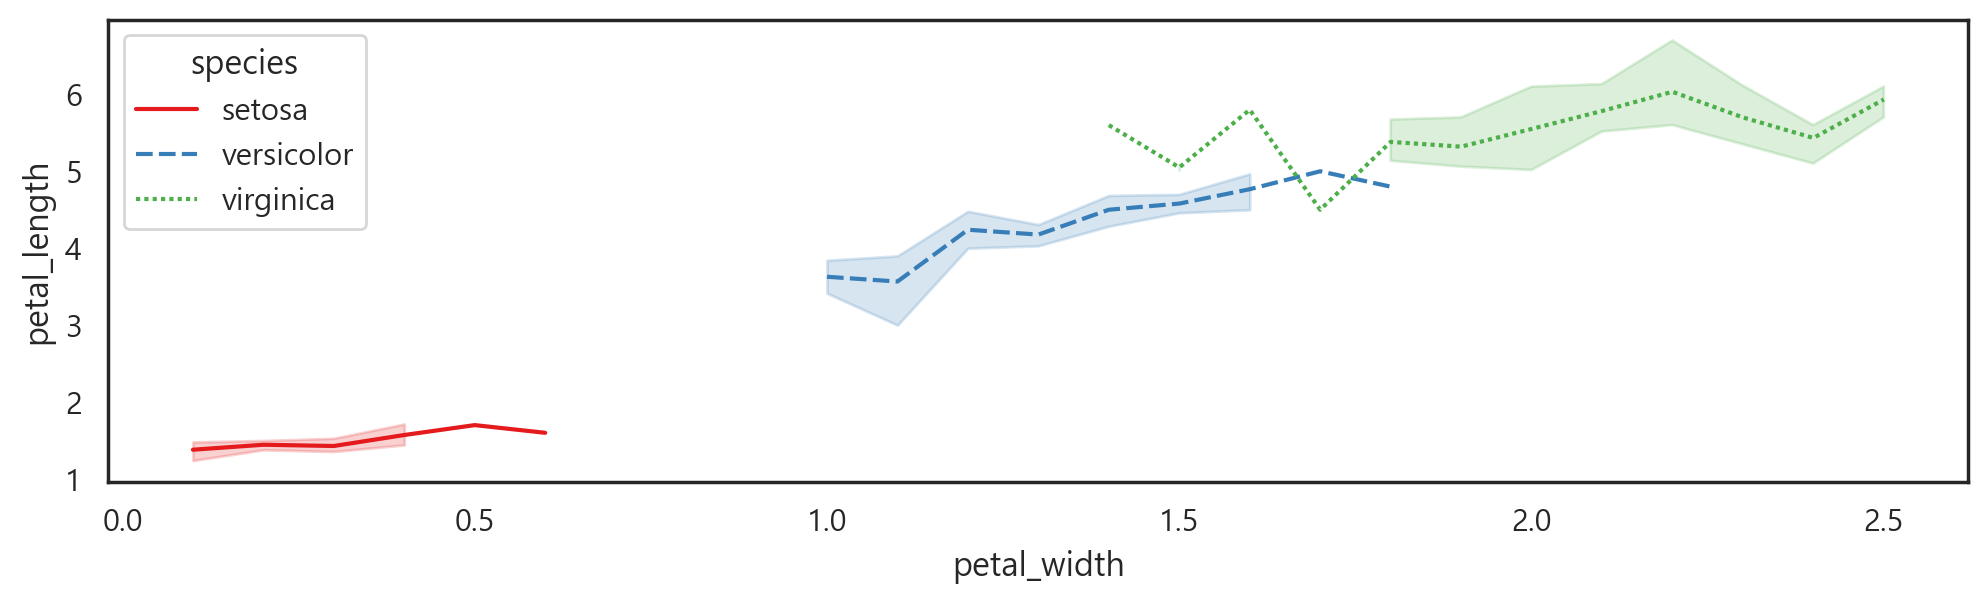

In [48]:
# 종별 다른 색상과 다른 스타일의 lineplot
sns.lineplot(data=iris, x='petal_width', y='petal_length', hue='species', 
             style='species', palette='Set1')
plt.show()

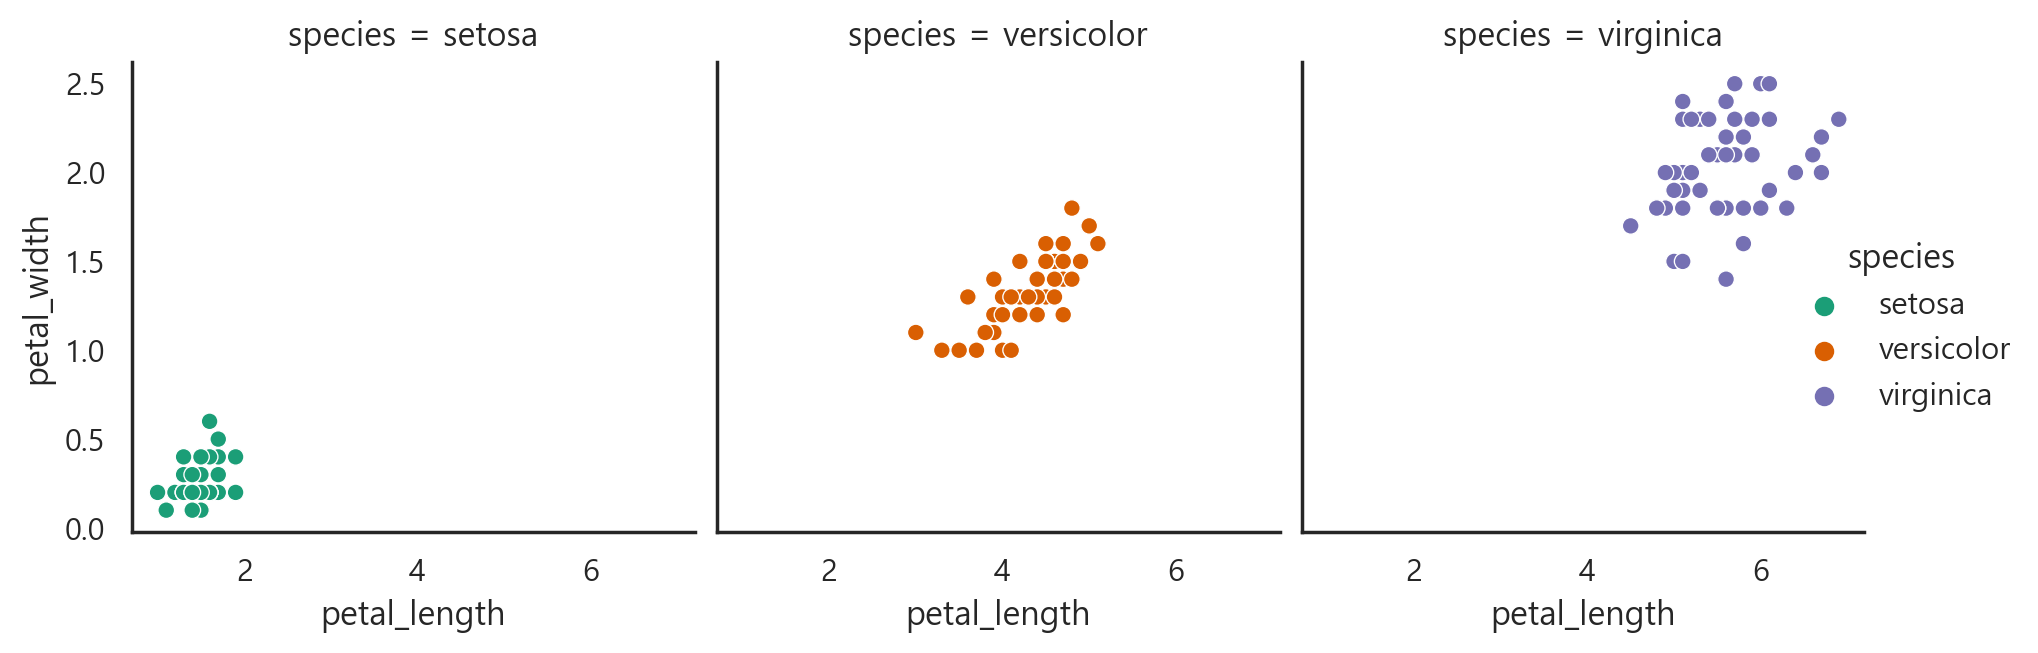

In [60]:
# 종별 scatterplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, x='petal_length', y='petal_width', hue='species',
           # 기본값은 kind='scatter',
           col='species', # col 단위로 서브플롯 표현
           # col_wrap=2,    # 한줄에 표현될 서브플롯 수 
           # facet_kws={'sharey':False, 'sharex':False}  # 축공유 여부
           )
g.fig.set_size_inches(10,3)
plt.show()

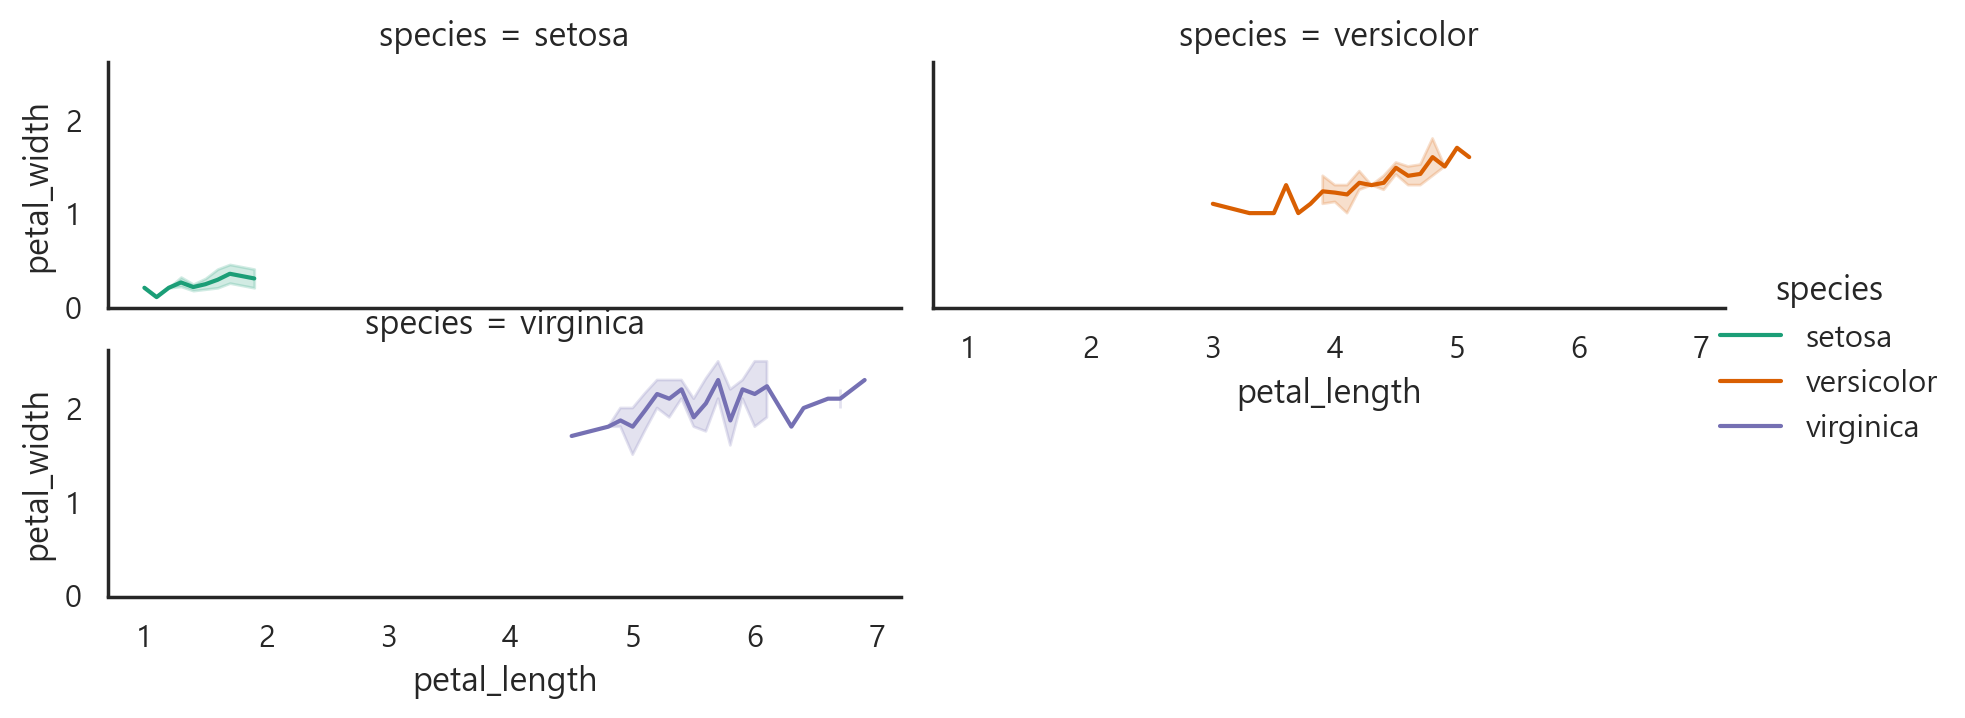

In [62]:
# 종별 lineplot을 서브플롯으로 => relplot(관계형 그래프에서 서브플롯을 그리는 함수)
g = sns.relplot(data=iris, 
                x='petal_length', 
                y='petal_width', 
                hue='species',
                kind='line',
                col='species', # col 단위로 서브플롯 표현
                col_wrap=2,    # 한줄에 표현될 서브플롯 수 
               # facet_kws={'sharey':False, 'sharex':False}  # 축공유 여부
           )
g.fig.set_size_inches(10,3)
plt.show()

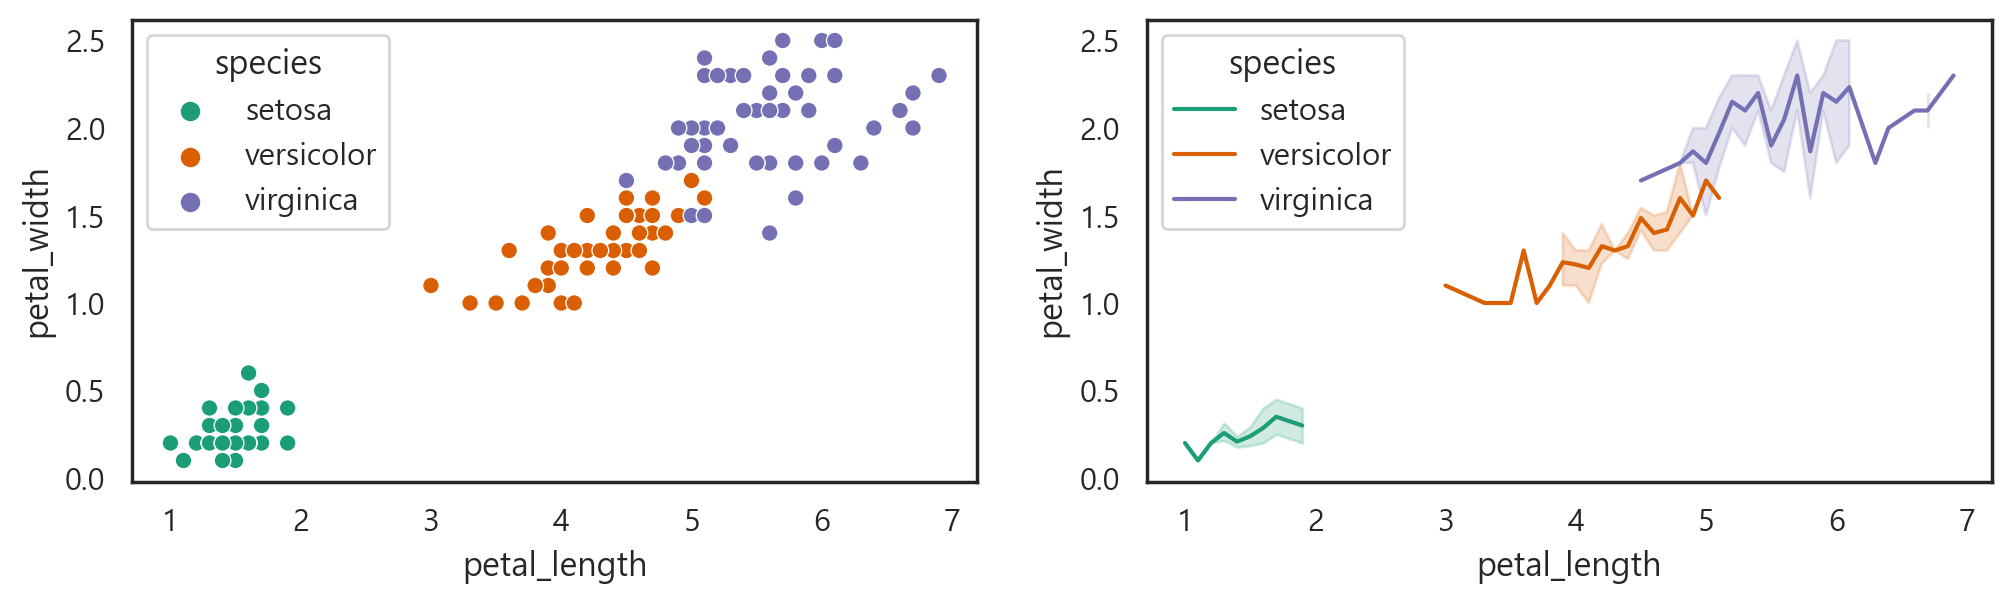

In [65]:
# 서브플롯 : scaterplot, lineplot
fig, ax = plt.subplots(1, 2)
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[0])
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species', ax=ax[1])
plt.show()

### 2) 범주형 그래프
- stripplot(무작위로 흩뿌림), swarmplot(겹치지않게뿌림)
- barplot, pointplot(bar와 높이는 같으나, 막대 대신 marker가 있는 선)
- countplot(bar는 y가 평균값높이, count는 y가 x의 빈도수가 높이)
- boxplot, violinplot, boxenplot                                => catplot(서브플롯)

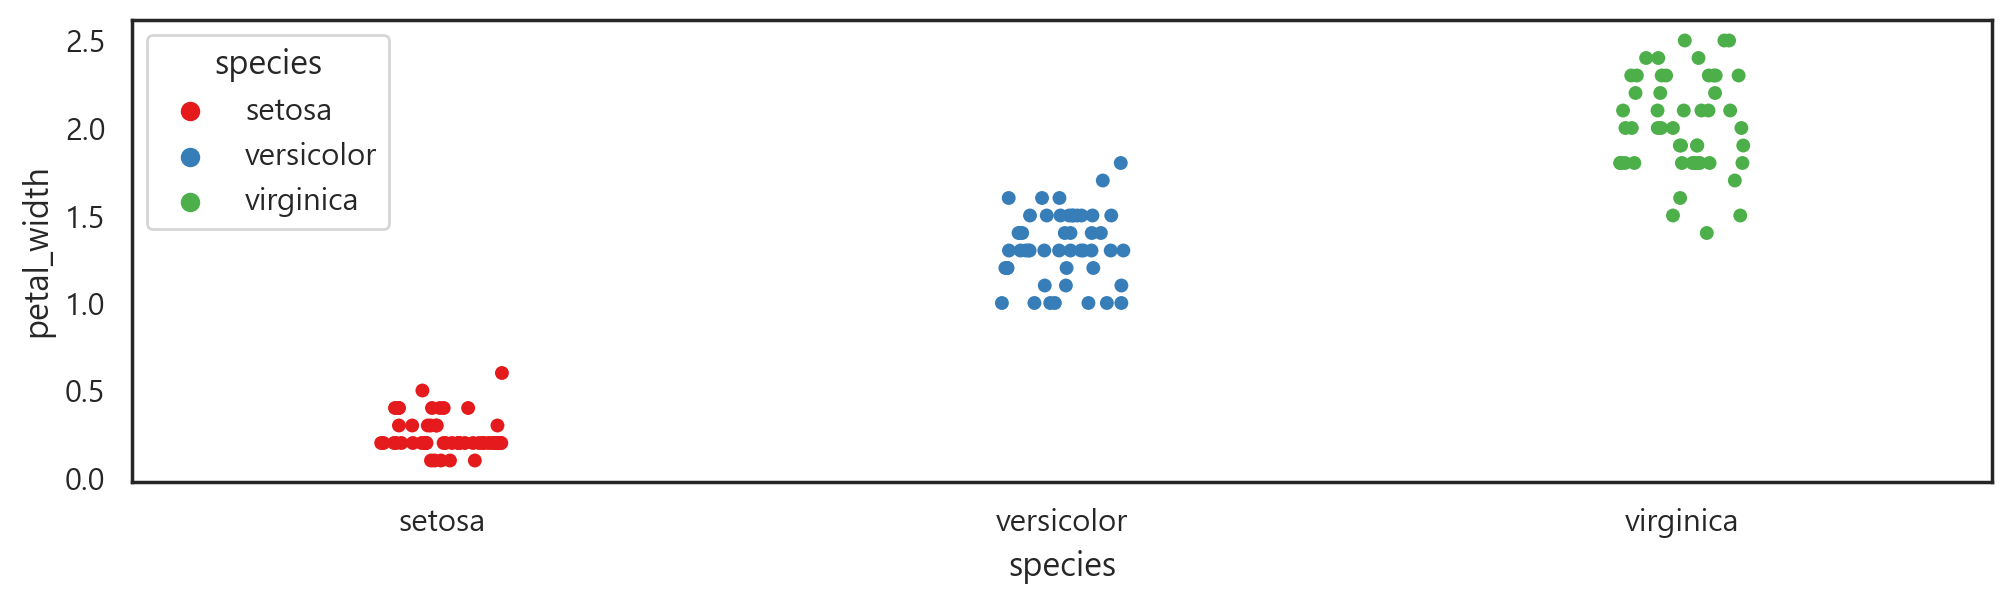

In [8]:
# x축이 범주형 데이터일 때 산점도(중첩된 점) : 랜덤하게 좌우로 약간씩 흩뿌려. 
sns.stripplot(data=iris, x='species', y='petal_width',
               hue='species', palette='Set1')
plt.show()

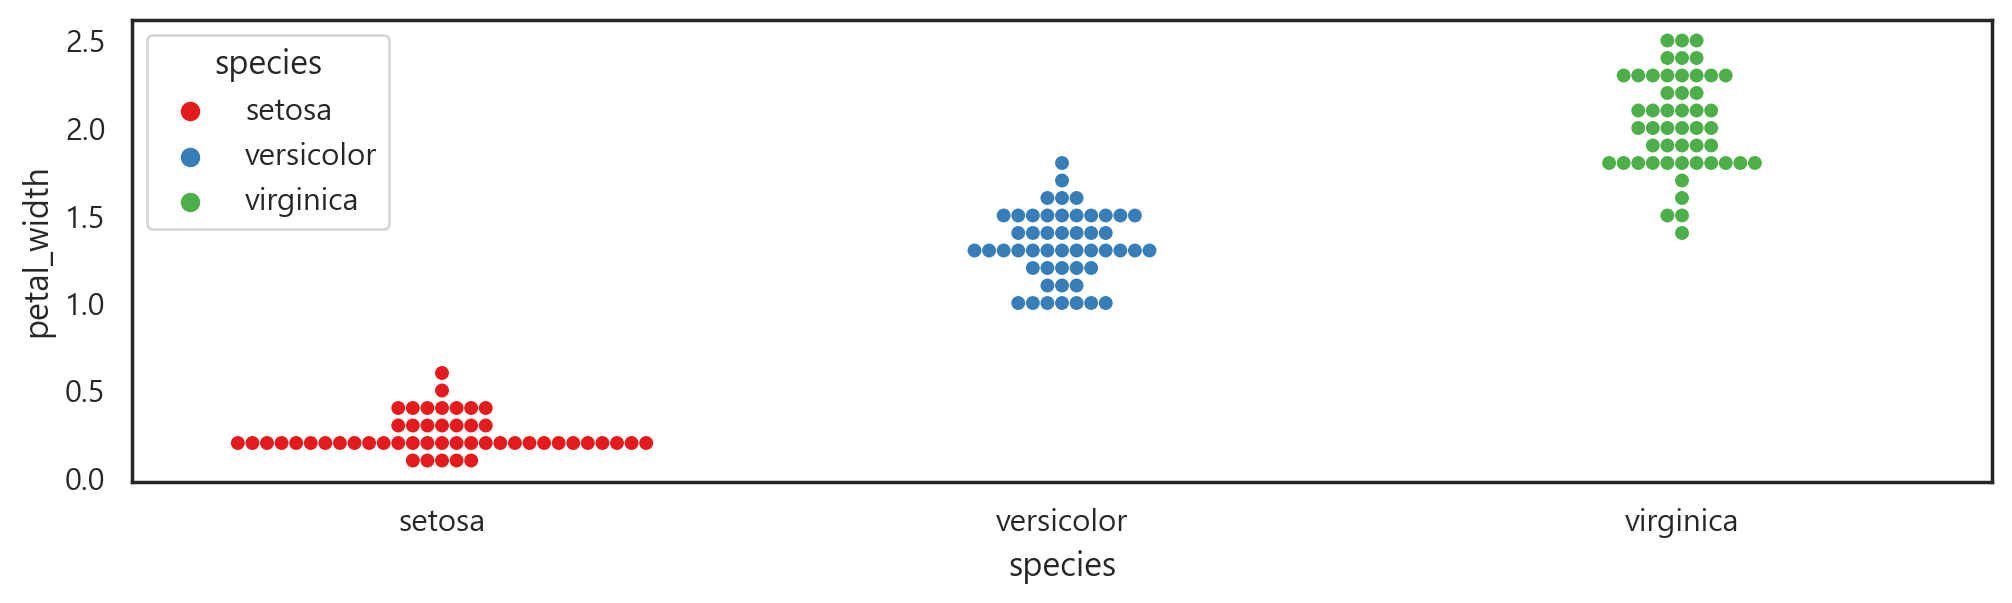

In [12]:
# x축이 범주형 데이터일 때 산점도(중첩되지 않게)
sns.swarmplot(data=iris, x='species', y='petal_width',
               hue='species', palette='Set1', #size=3
             )
plt.show()

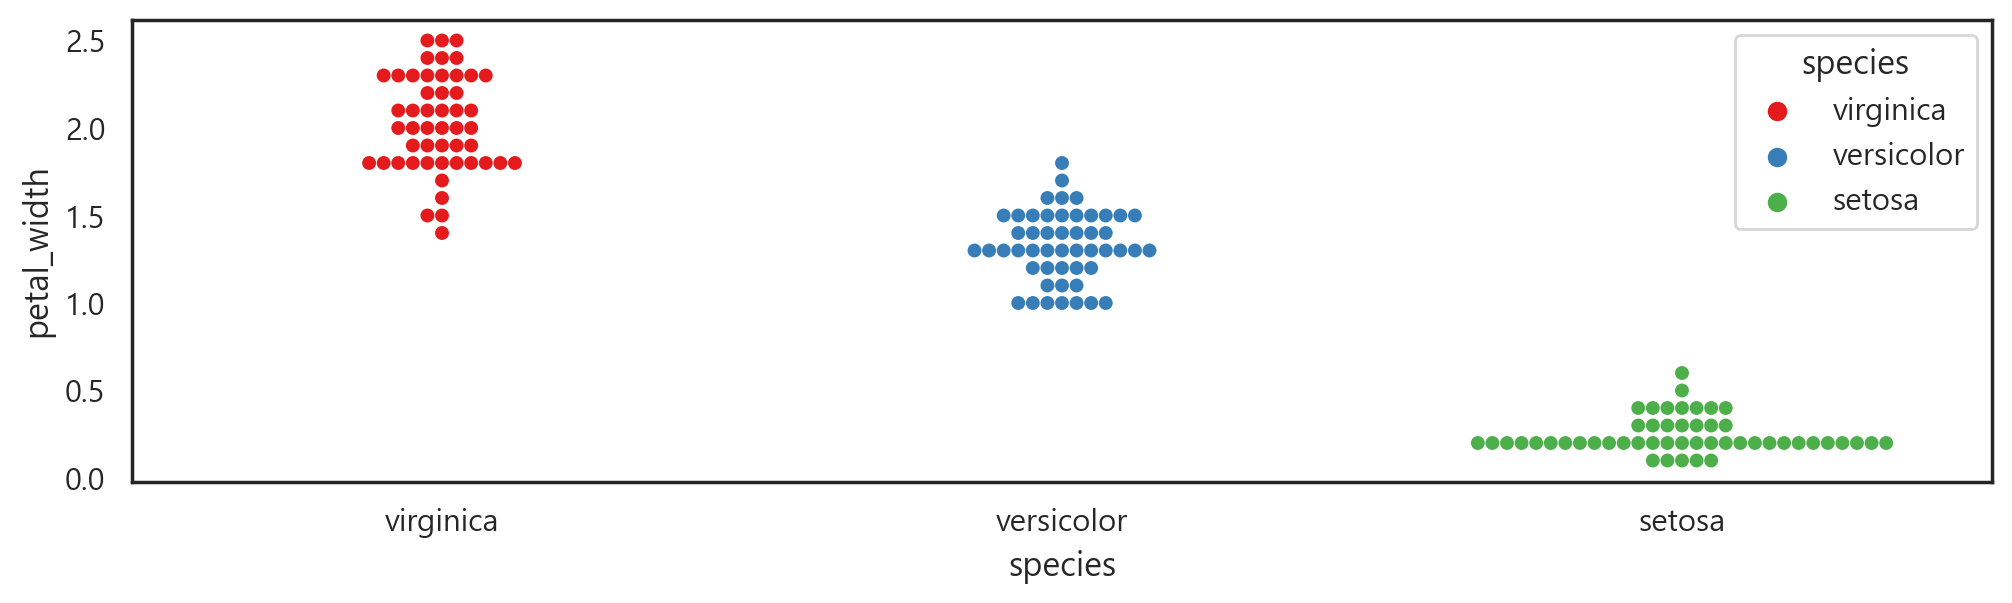

In [20]:
# petal_width 내림차순 정렬된 iris로 종별 산점도
sns.swarmplot(data=iris.sort_values('petal_width', ascending=False),
             x='species',
             y='petal_width',
             hue='species',
             palette='Set1') # https://wikidocs.net/92085
plt.show()

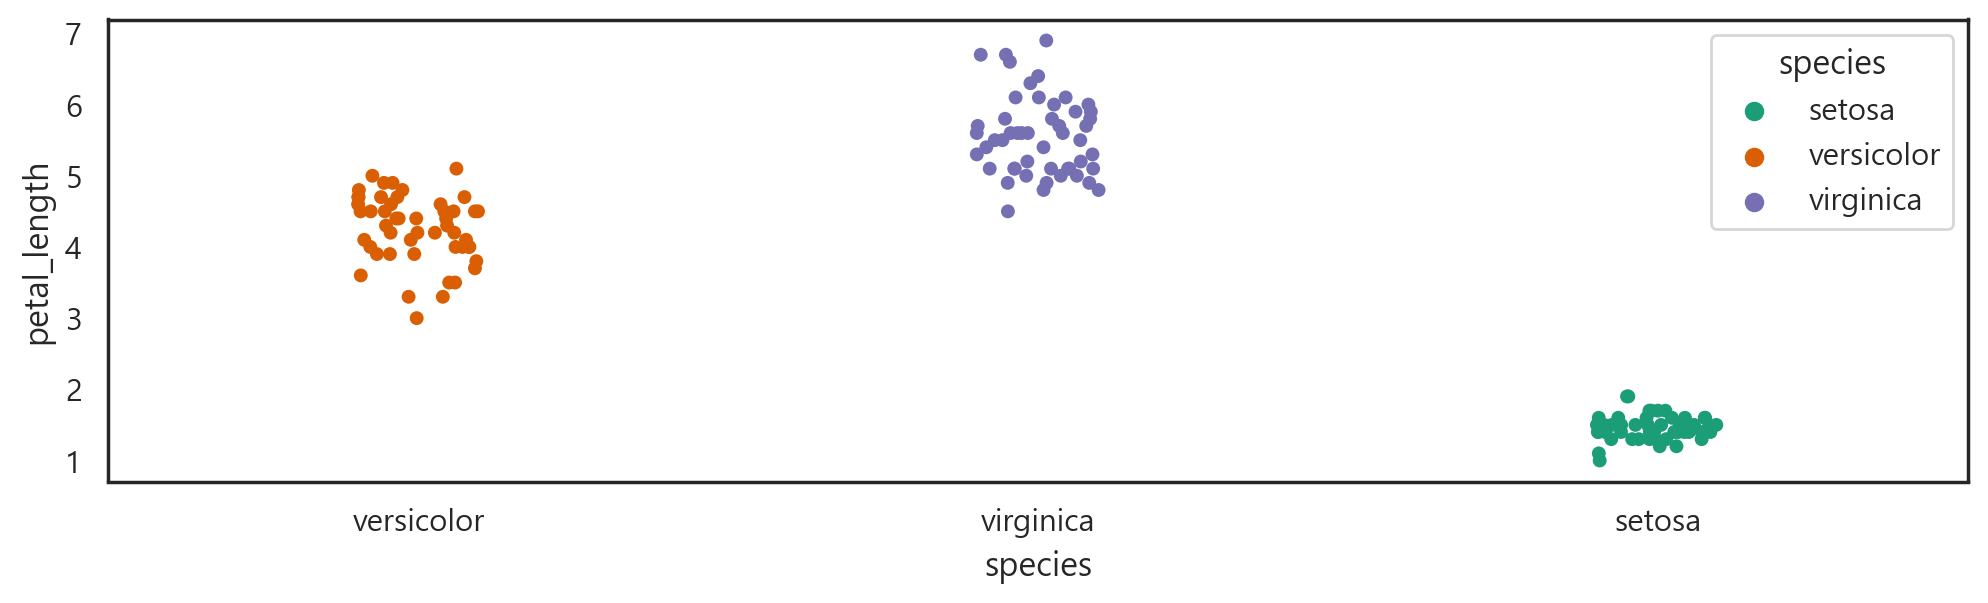

In [23]:
# x축 순서를 임의로 정할 수 있음
sns.stripplot(data=iris,
             x='species',
             y='petal_length',
             order=['versicolor', 'virginica', 'setosa'], # x축 순서
             hue='species')
plt.show()

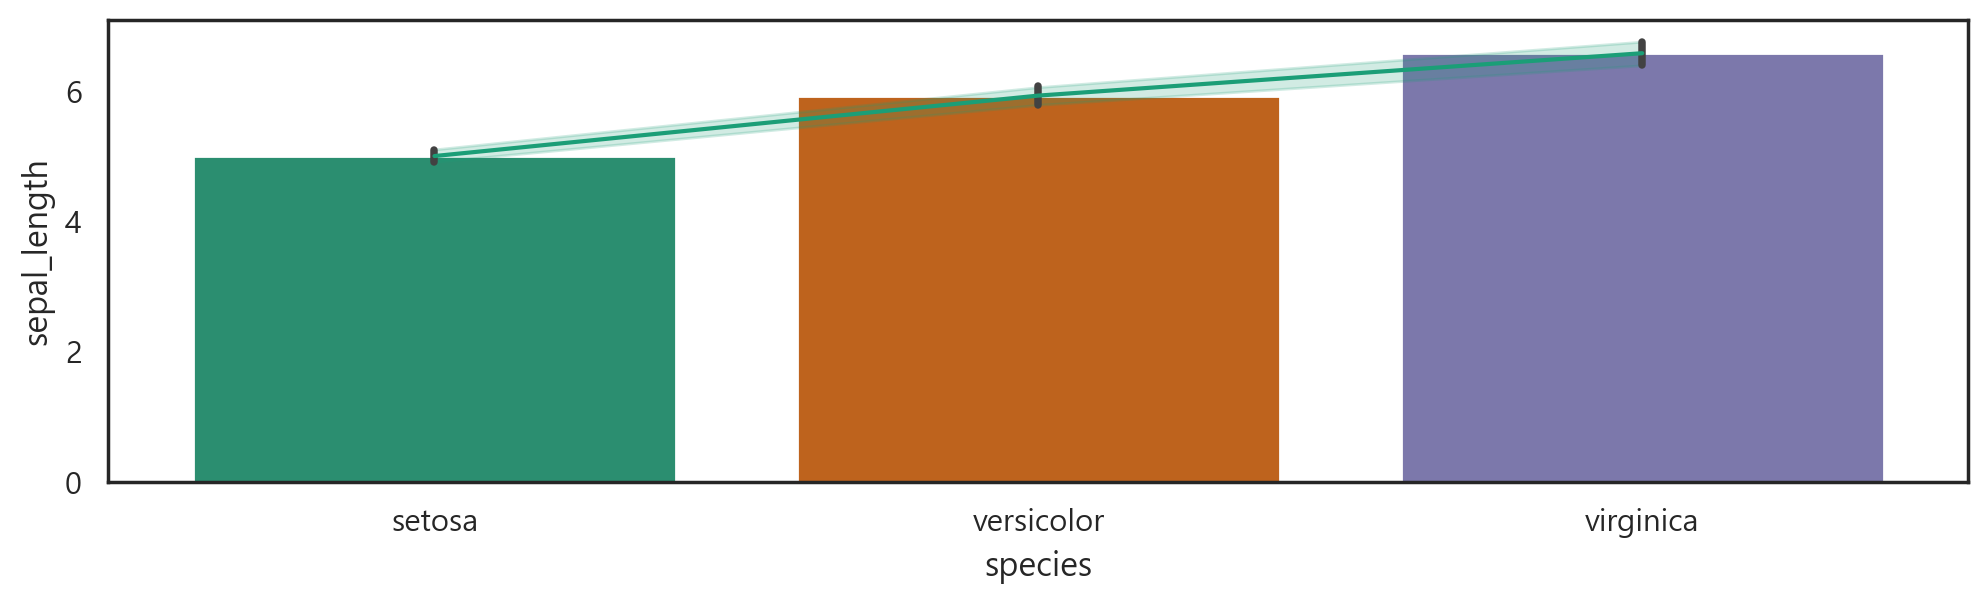

In [33]:
# barplot : 각 범주별 평균값과 그에 대한 신뢰구간(ci:confidence interval)을 막대 그래프
sns.barplot(data=iris,
           x='species',
           y='sepal_length',
           #errorbar=None, # ci구간을 안그리고 막대만
           # estimator='sum' 
           )
sns.lineplot(data=iris,
            x='species',
            y='sepal_length')
plt.show()

<Axes: xlabel='species', ylabel='sepal_length'>

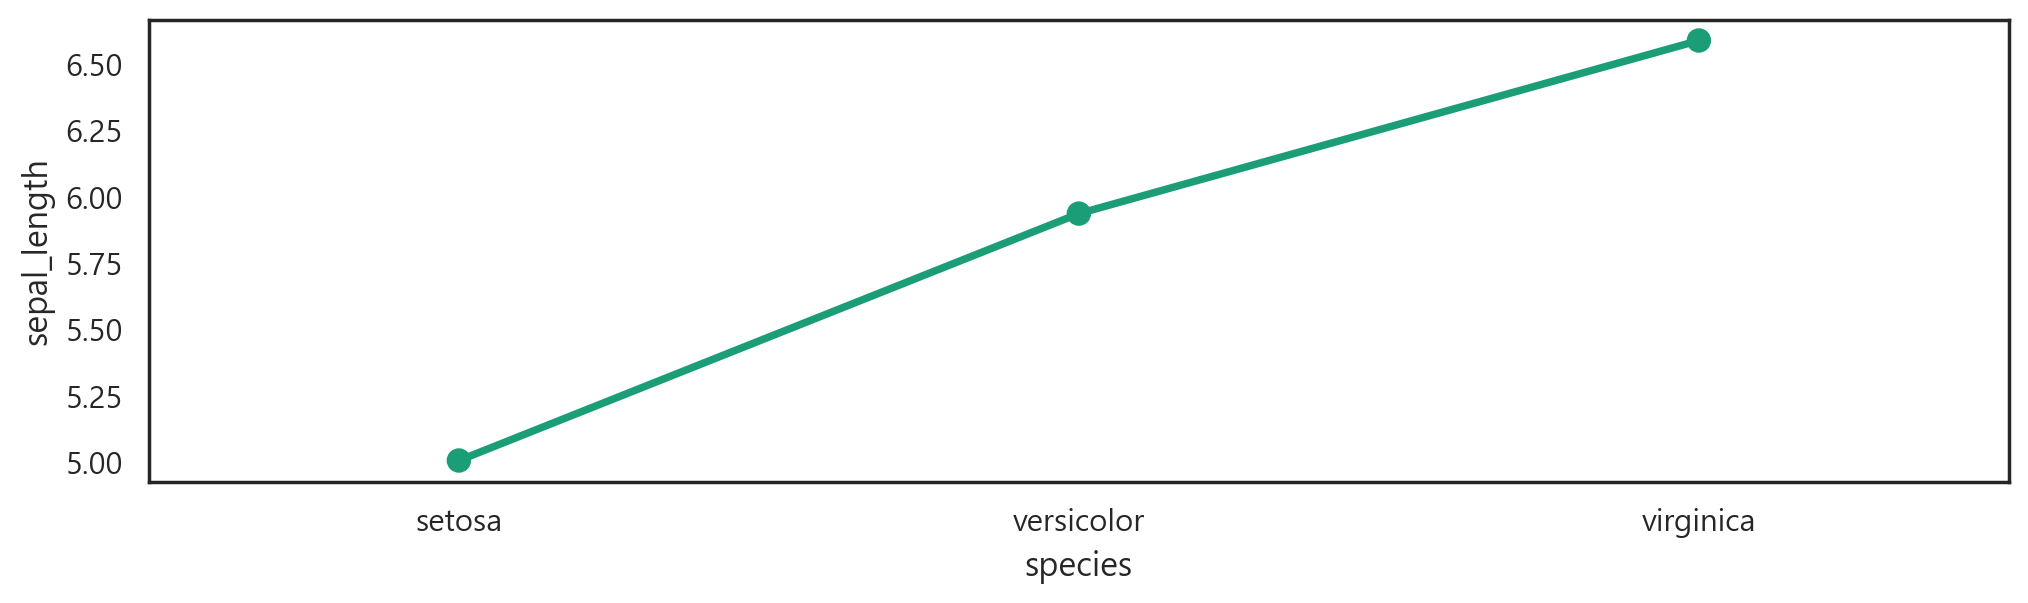

In [34]:
sns.pointplot(data=iris,
           x='species',
           y='sepal_length',
           errorbar=None)

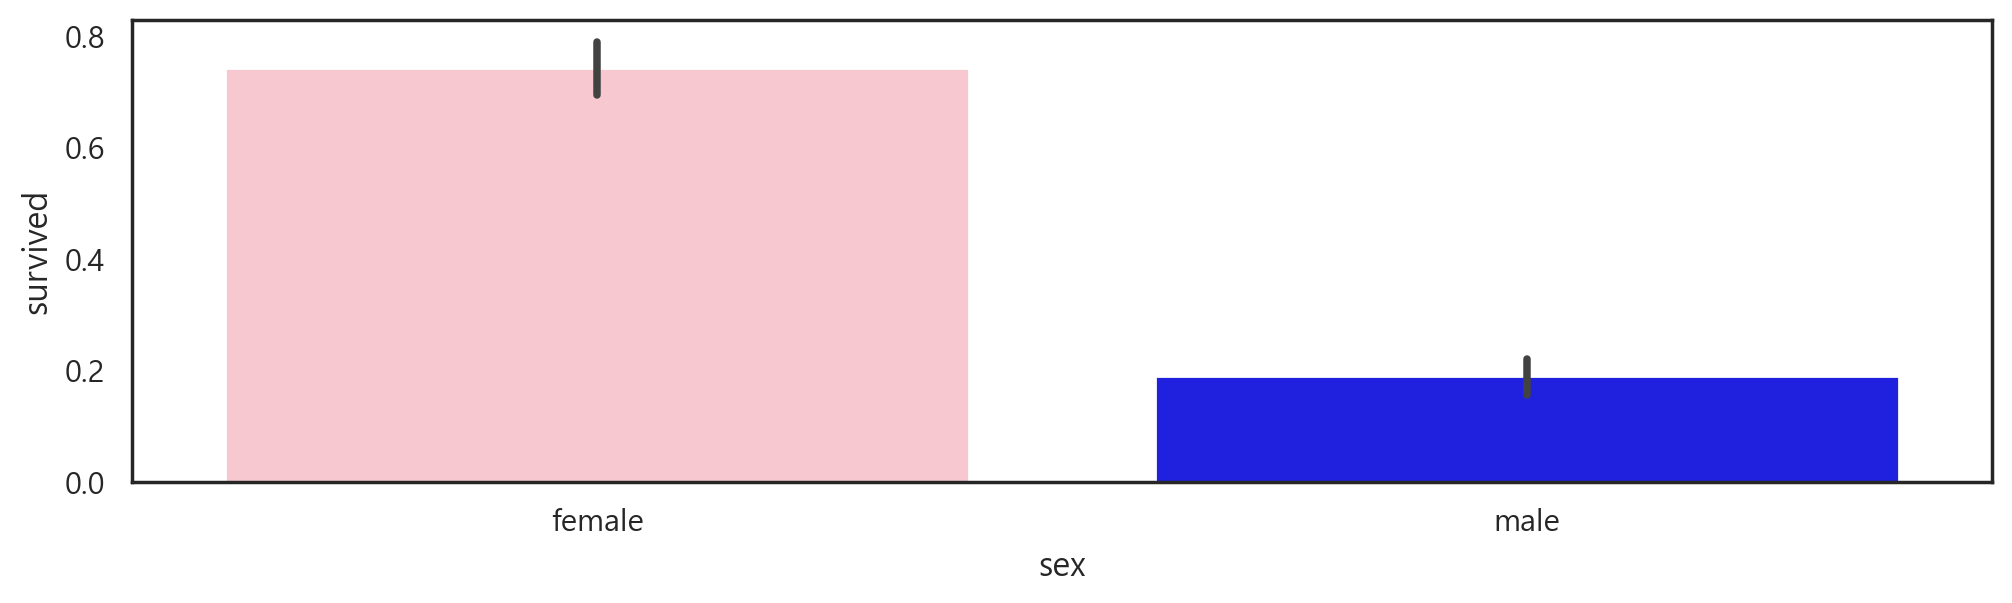

In [40]:
# titanic의 성별 평균 생존률
# titanic.groupby('sex')['survived'].mean()
sns.barplot(data=titanic, x='sex', y='survived', 
            order=['female','male'],
            palette=['pink','blue'])
plt.show()

In [42]:
titanic['sex'].unique()

array(['male', 'female'], dtype=object)

In [48]:
# 성별 데이터 수
titanic.groupby('sex')['survived'].count().sort_values(ascending=False)
titanic['sex'].value_counts() # 내림차순 정렬

male      577
female    314
Name: sex, dtype: int64

In [54]:
# 남자 중 생존자와 비생존자
print('남자 생존자 수 :', titanic[(titanic['sex']=='male') & (titanic['survived']==1)].shape[0])
print('남자 생존자 수 :', len(titanic[(titanic['sex']=='male') & (titanic['survived']==1)]))
print('남자 비생존자 수 :', titanic[(titanic['sex']=='male') & (titanic['survived']==0)].shape[0])
print('남자 비생존자 수 :', len(titanic[(titanic['sex']=='male') & (titanic['survived']==0)]))

남자 생존자 수 : 109
남자 생존자 수 : 109
남자 비생존자 수 : 468
남자 비생존자 수 : 468


In [55]:
# 여자 중 생존자와 비생존자
print('여자 생존자 수 :', titanic[(titanic['sex']=='female') & (titanic['survived']==1)].shape[0])
print('여자 생존자 수 :', len(titanic[(titanic['sex']=='female') & (titanic['survived']==1)]))
print('여자 비생존자 수 :', titanic[(titanic['sex']=='female') & (titanic['survived']==0)].shape[0])
print('여자 비생존자 수 :', len(titanic[(titanic['sex']=='female') & (titanic['survived']==0)]))

여자 생존자 수 : 233
여자 생존자 수 : 233
여자 비생존자 수 : 81
여자 비생존자 수 : 81


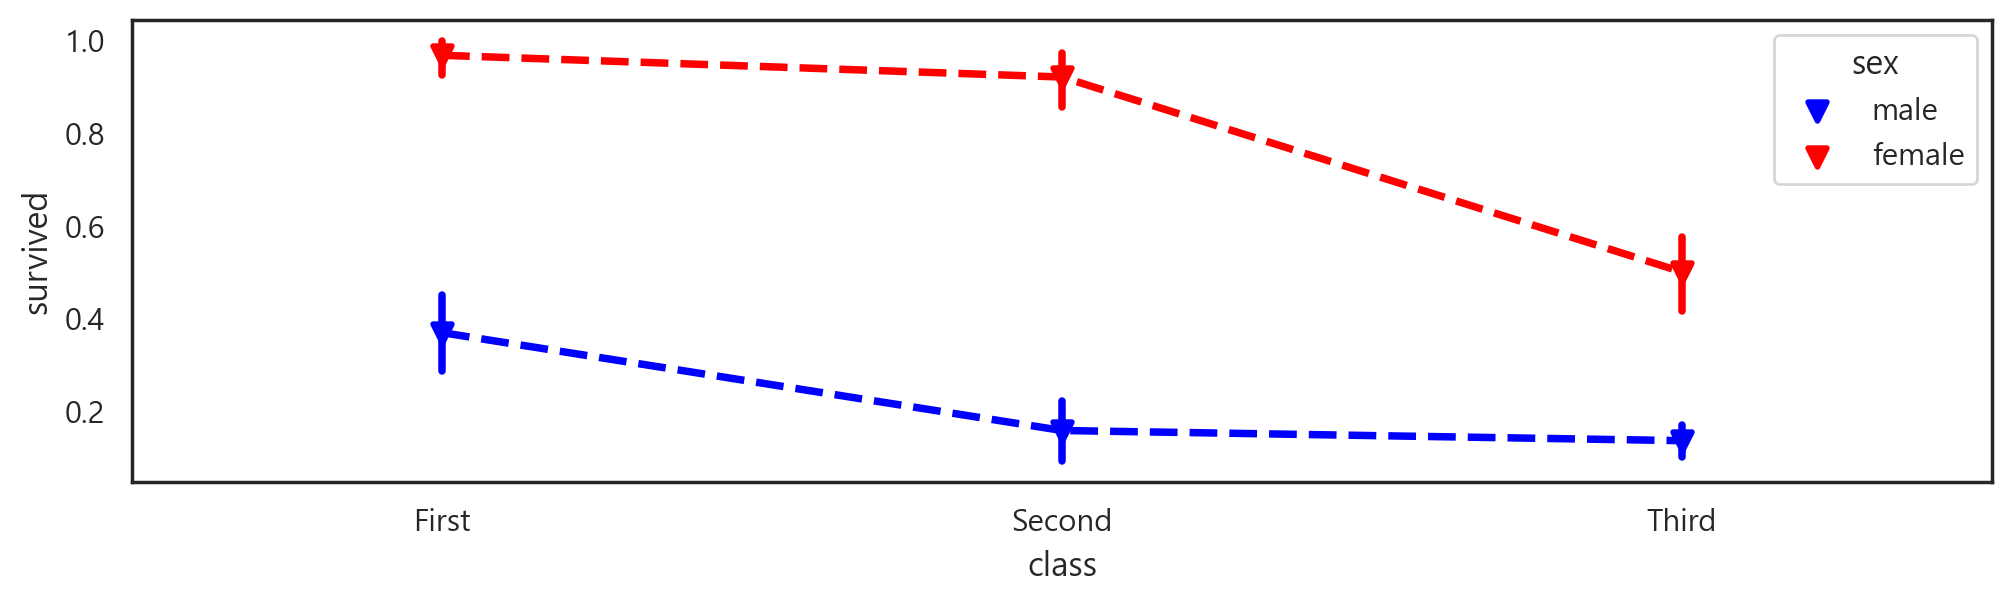

In [103]:
# class별 평균 생존률
sns.pointplot(data=titanic, x='class', y='survived',
              hue='sex',
              markers='v',linestyles='--',
             # palette='Set1',
             # palette=['blue','red'],
             palette={'female':'r', 'male':'b'})
plt.show()

<Axes: xlabel='sex', ylabel='survived'>

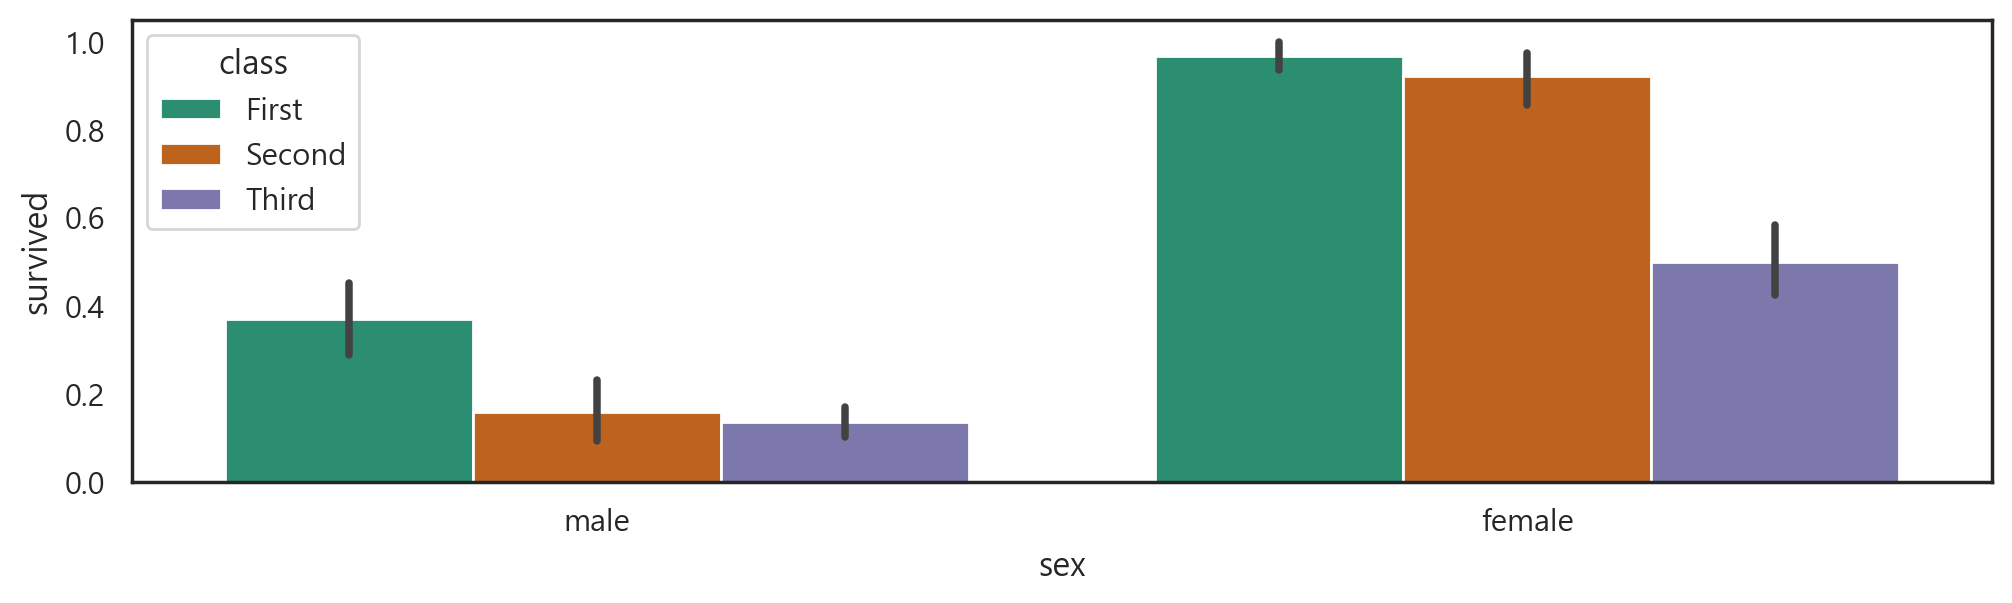

In [60]:
# class별 성별 생존률
sns.barplot(data=titanic, x='sex', y='survived', hue='class')
plt.show()

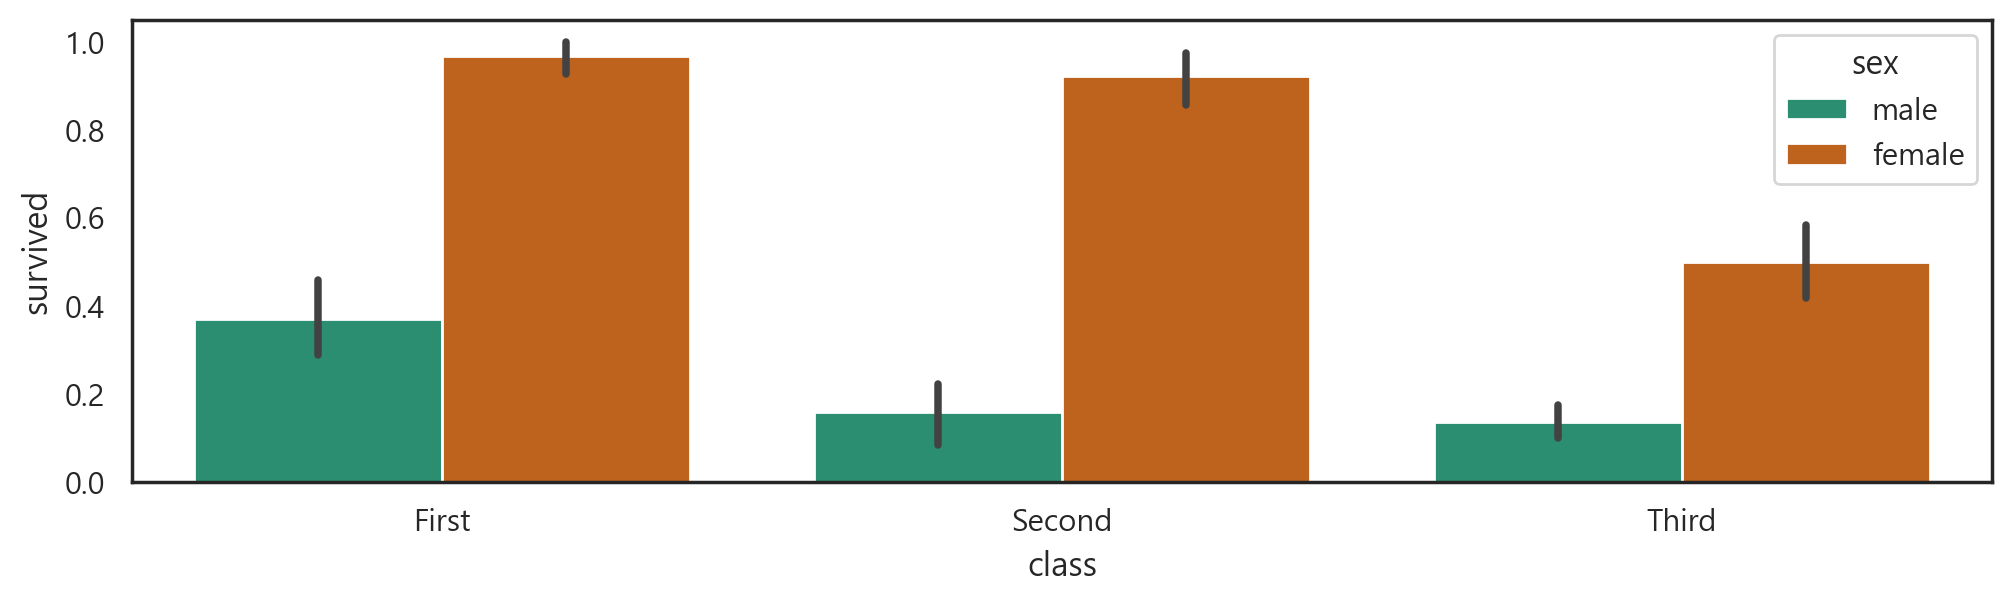

In [61]:
# class별 성별 생존률
sns.barplot(data=titanic, x='class', y='survived', hue='sex')
plt.show()

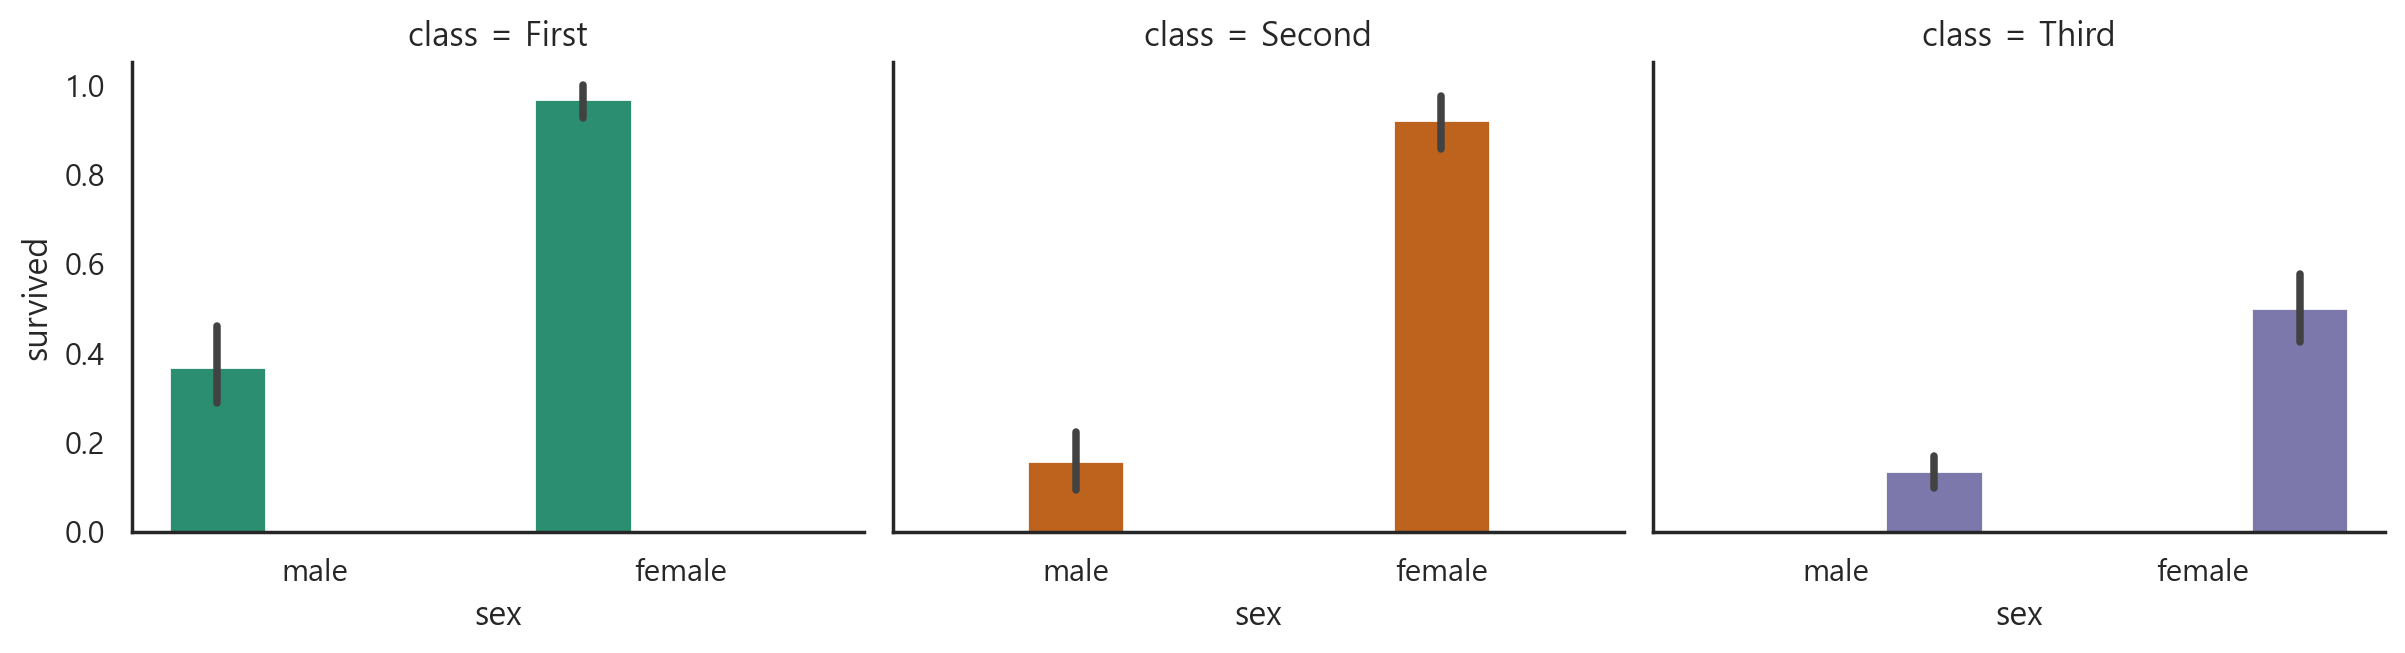

In [69]:
# class별로 성별 생존률 서브플롯으로(barplot)
g = sns.catplot(data=titanic,
               x='sex',
               y='survived',
               kind='bar', # 기본값은 stripplot
               col='class',
               hue='class',
               # col_wrap=2  # 한행에 그려질 서브플롯 수
               )
g.fig.set_size_inches(12,3)

In [84]:
order = titanic.groupby('deck')['survived'].mean().sort_values(ascending=False).index

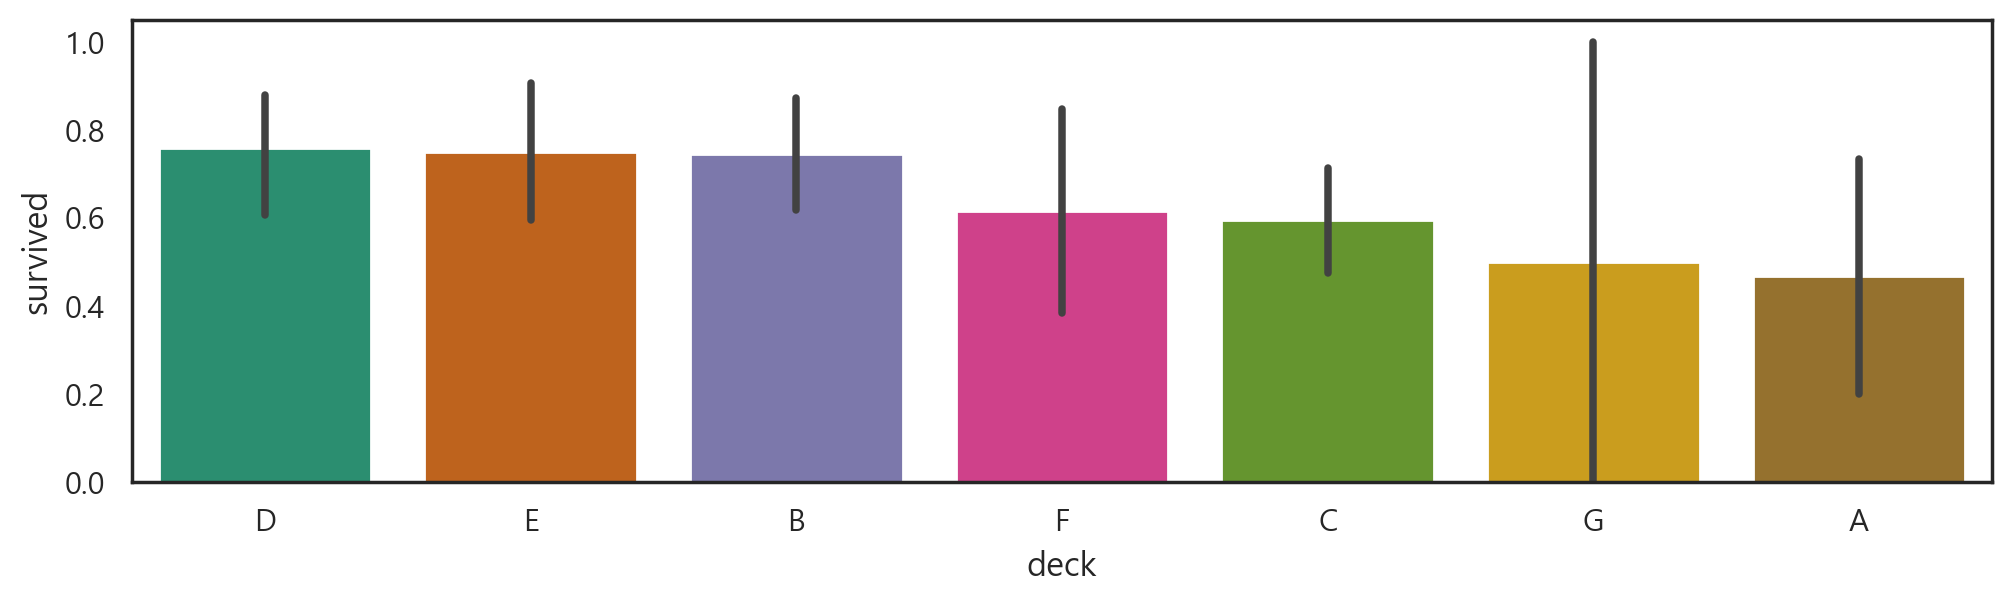

In [85]:
# deck별 생존률(결측치가 많아 신뢰도 낮음)
sns.barplot(data=titanic, 
            x='deck', y='survived',
           order = order)
plt.show()

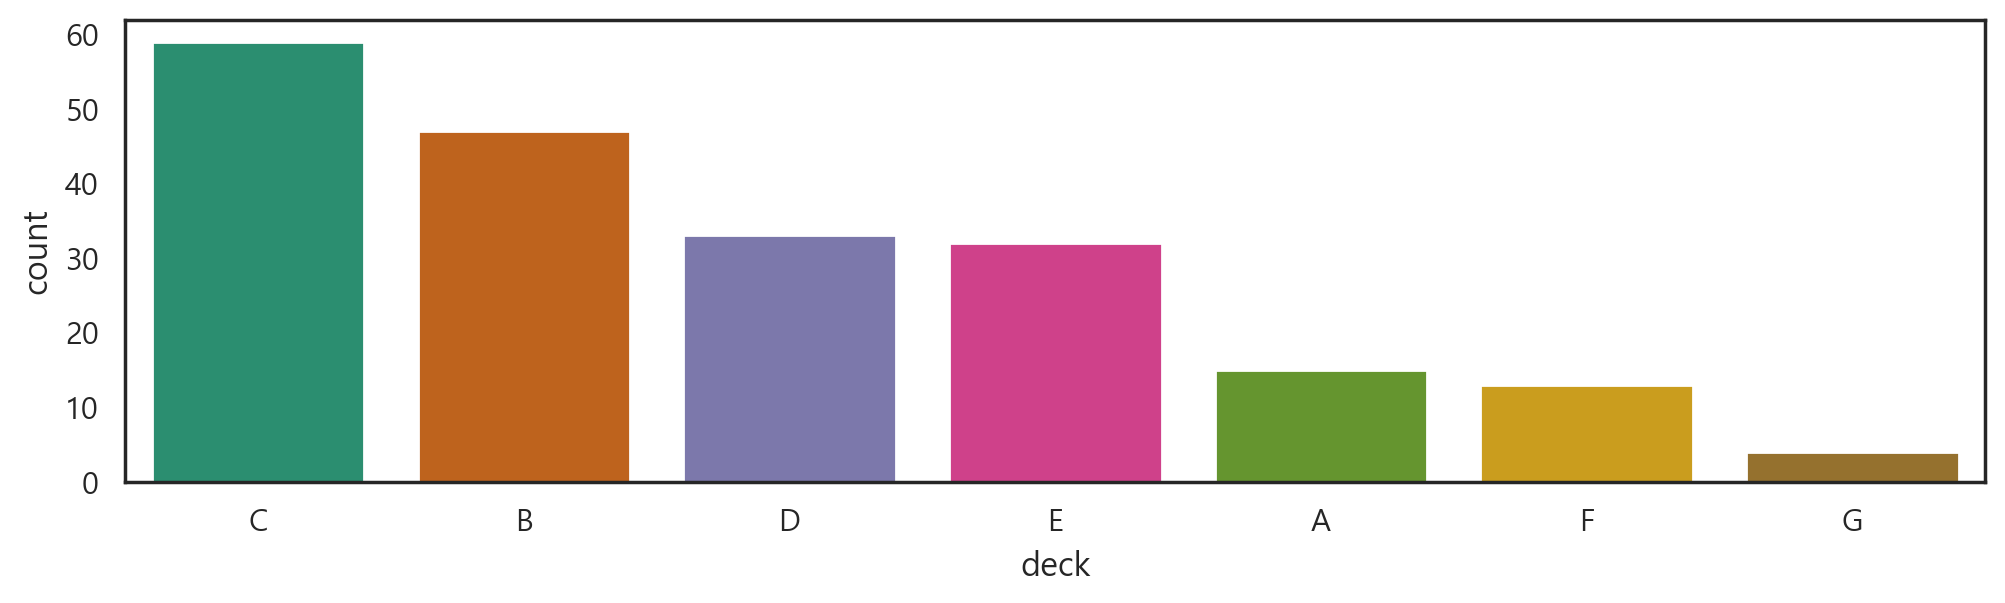

In [89]:
# deck별 데이터 수를 막대그래프
order = titanic.deck.value_counts().index
sns.countplot(data=titanic, x='deck', order=order)
plt.show()

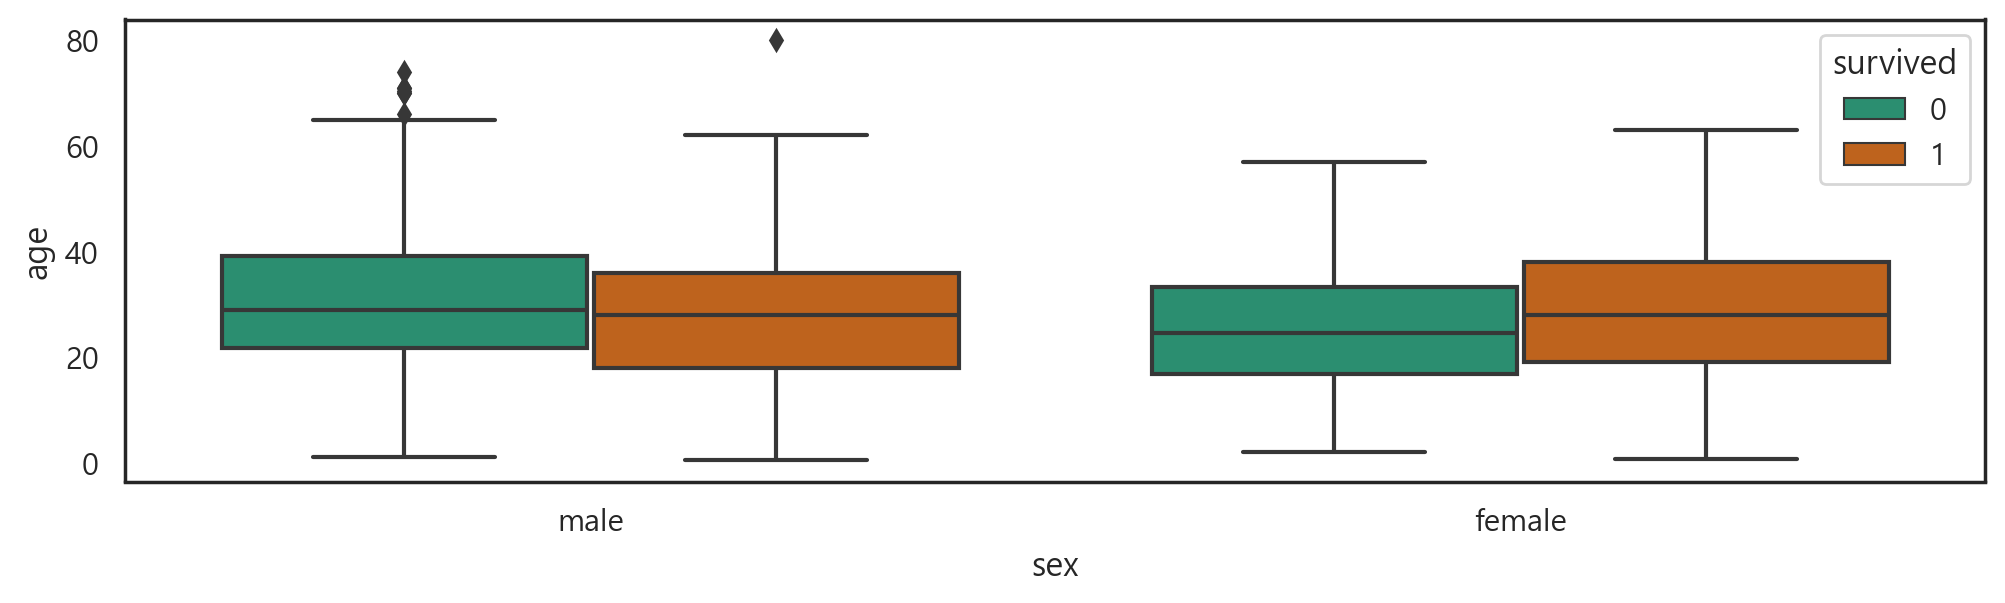

In [107]:
# boxplot (4사분위수와 이상치 판별. 분포는 모름) => boxenplot, violinplot
sns.boxplot(data=titanic, x='sex', y='age', hue='survived')
plt.show()

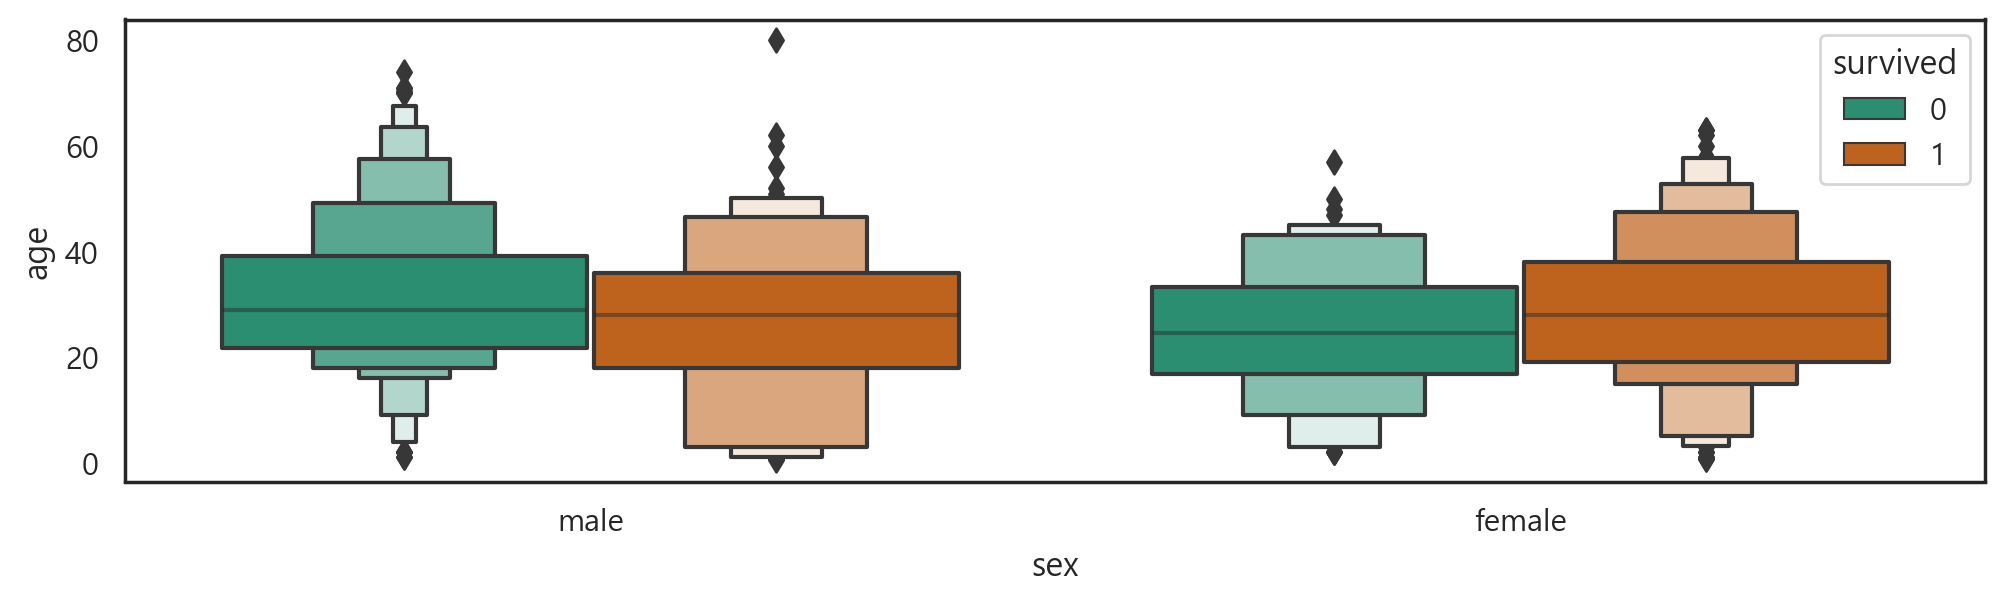

In [108]:
sns.boxenplot(data=titanic, x='sex', y='age', hue='survived')
plt.show()

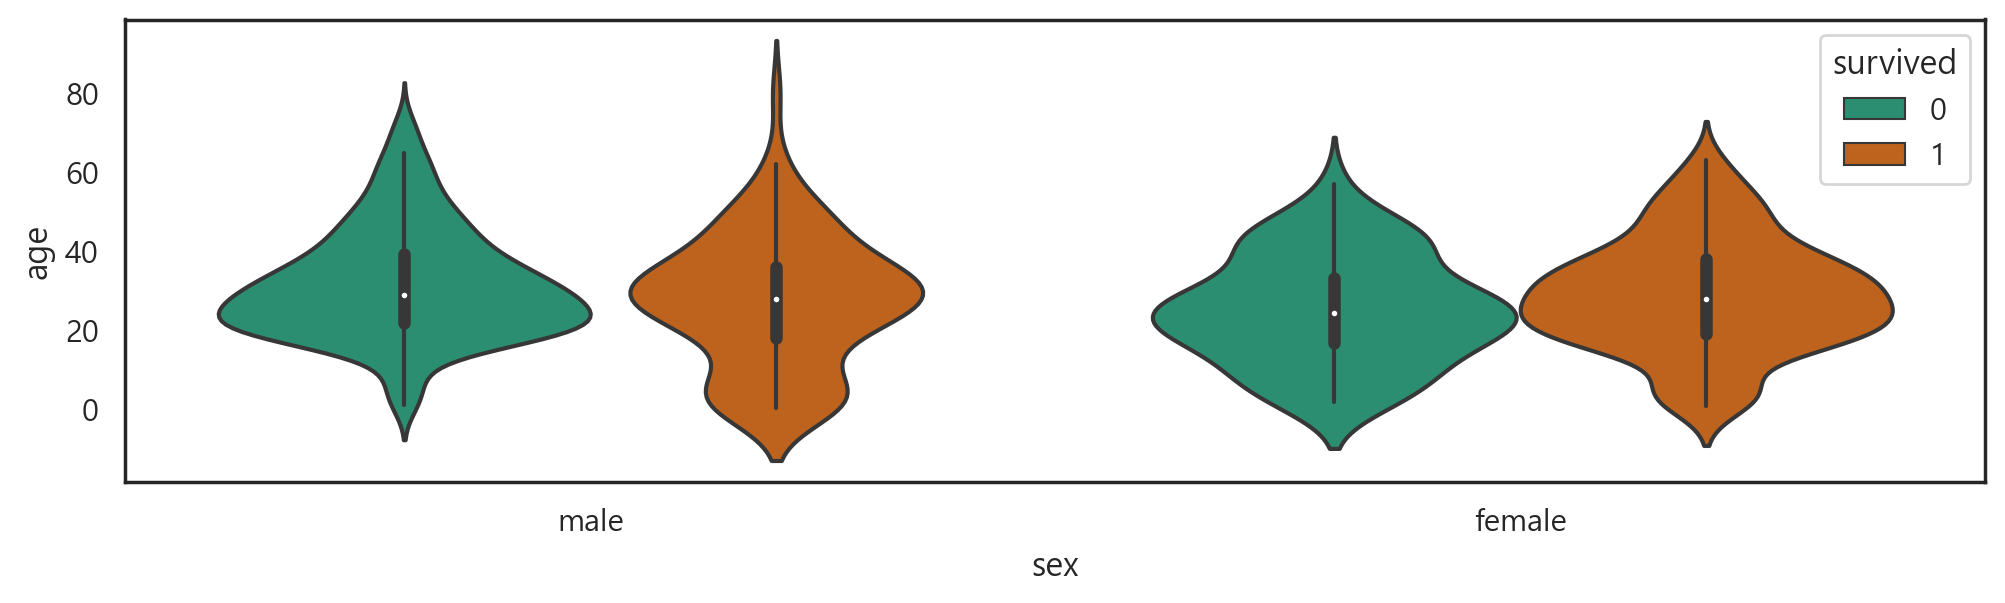

In [109]:
sns.violinplot(data=titanic, x='sex', y='age', hue='survived')
plt.show()

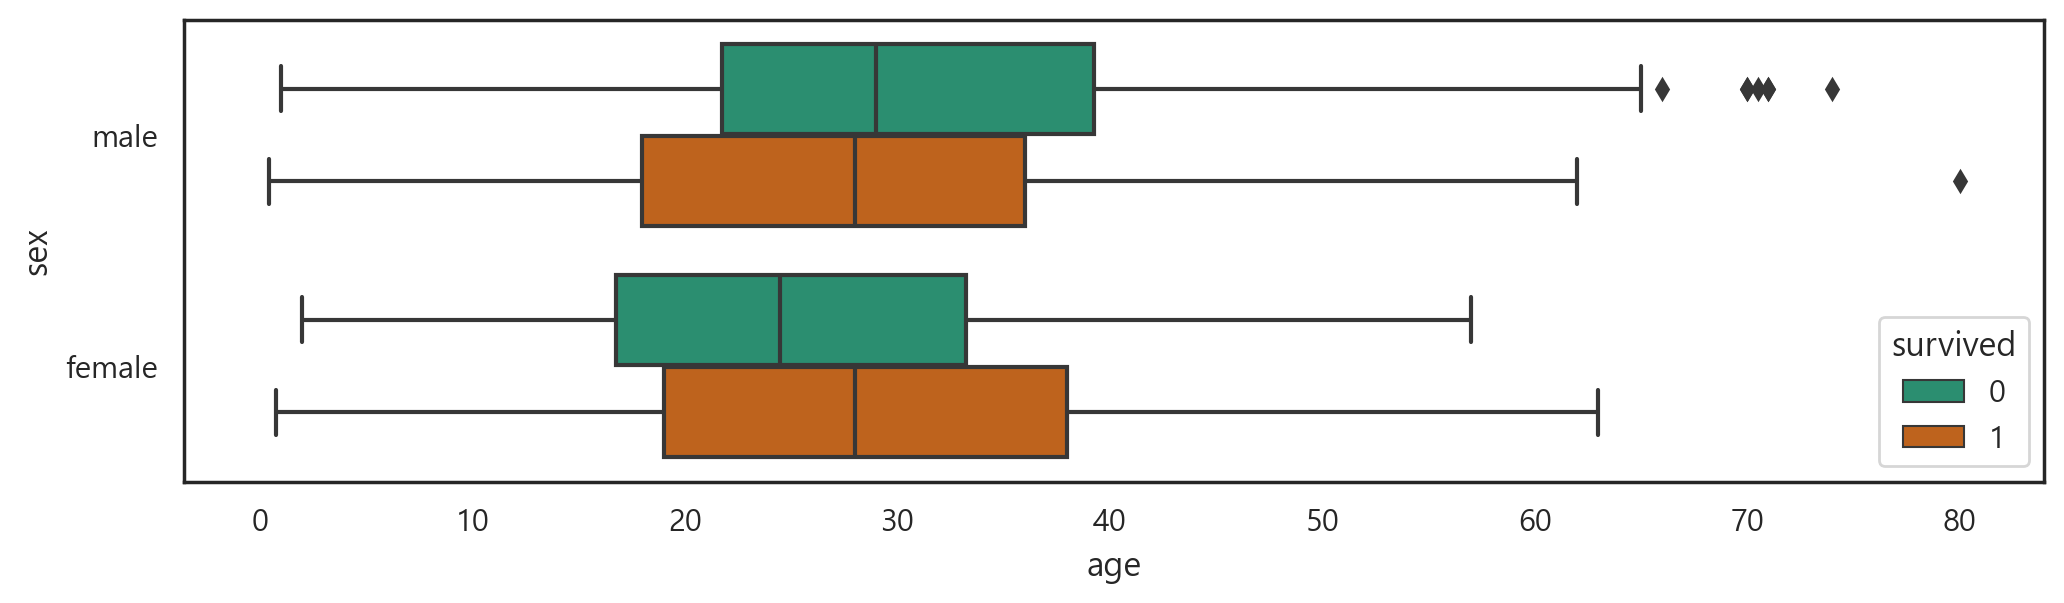

In [110]:
sns.boxplot(data=titanic, y='sex', x='age', hue='survived')
plt.show()

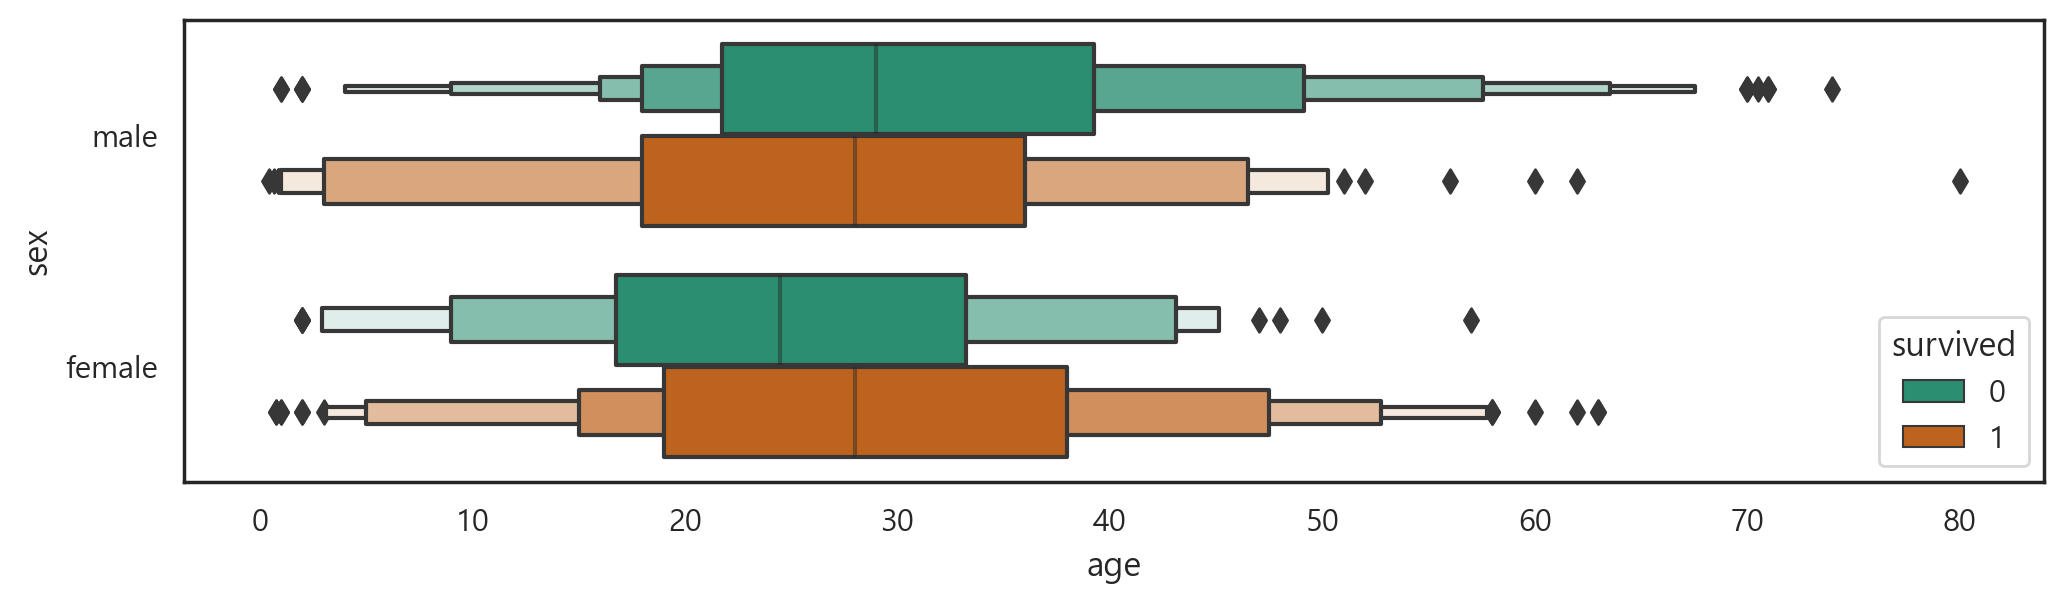

In [111]:
sns.boxenplot(data=titanic, y='sex', x='age', hue='survived')
plt.show()

### 3) 쌍관계그래프
- pairplot : 데이터프레임에 포한된 모든 수치형 변수의 쌍에 대해 산점도(scatterplot)와 히스토그램(histplot)을 보여줌

In [115]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


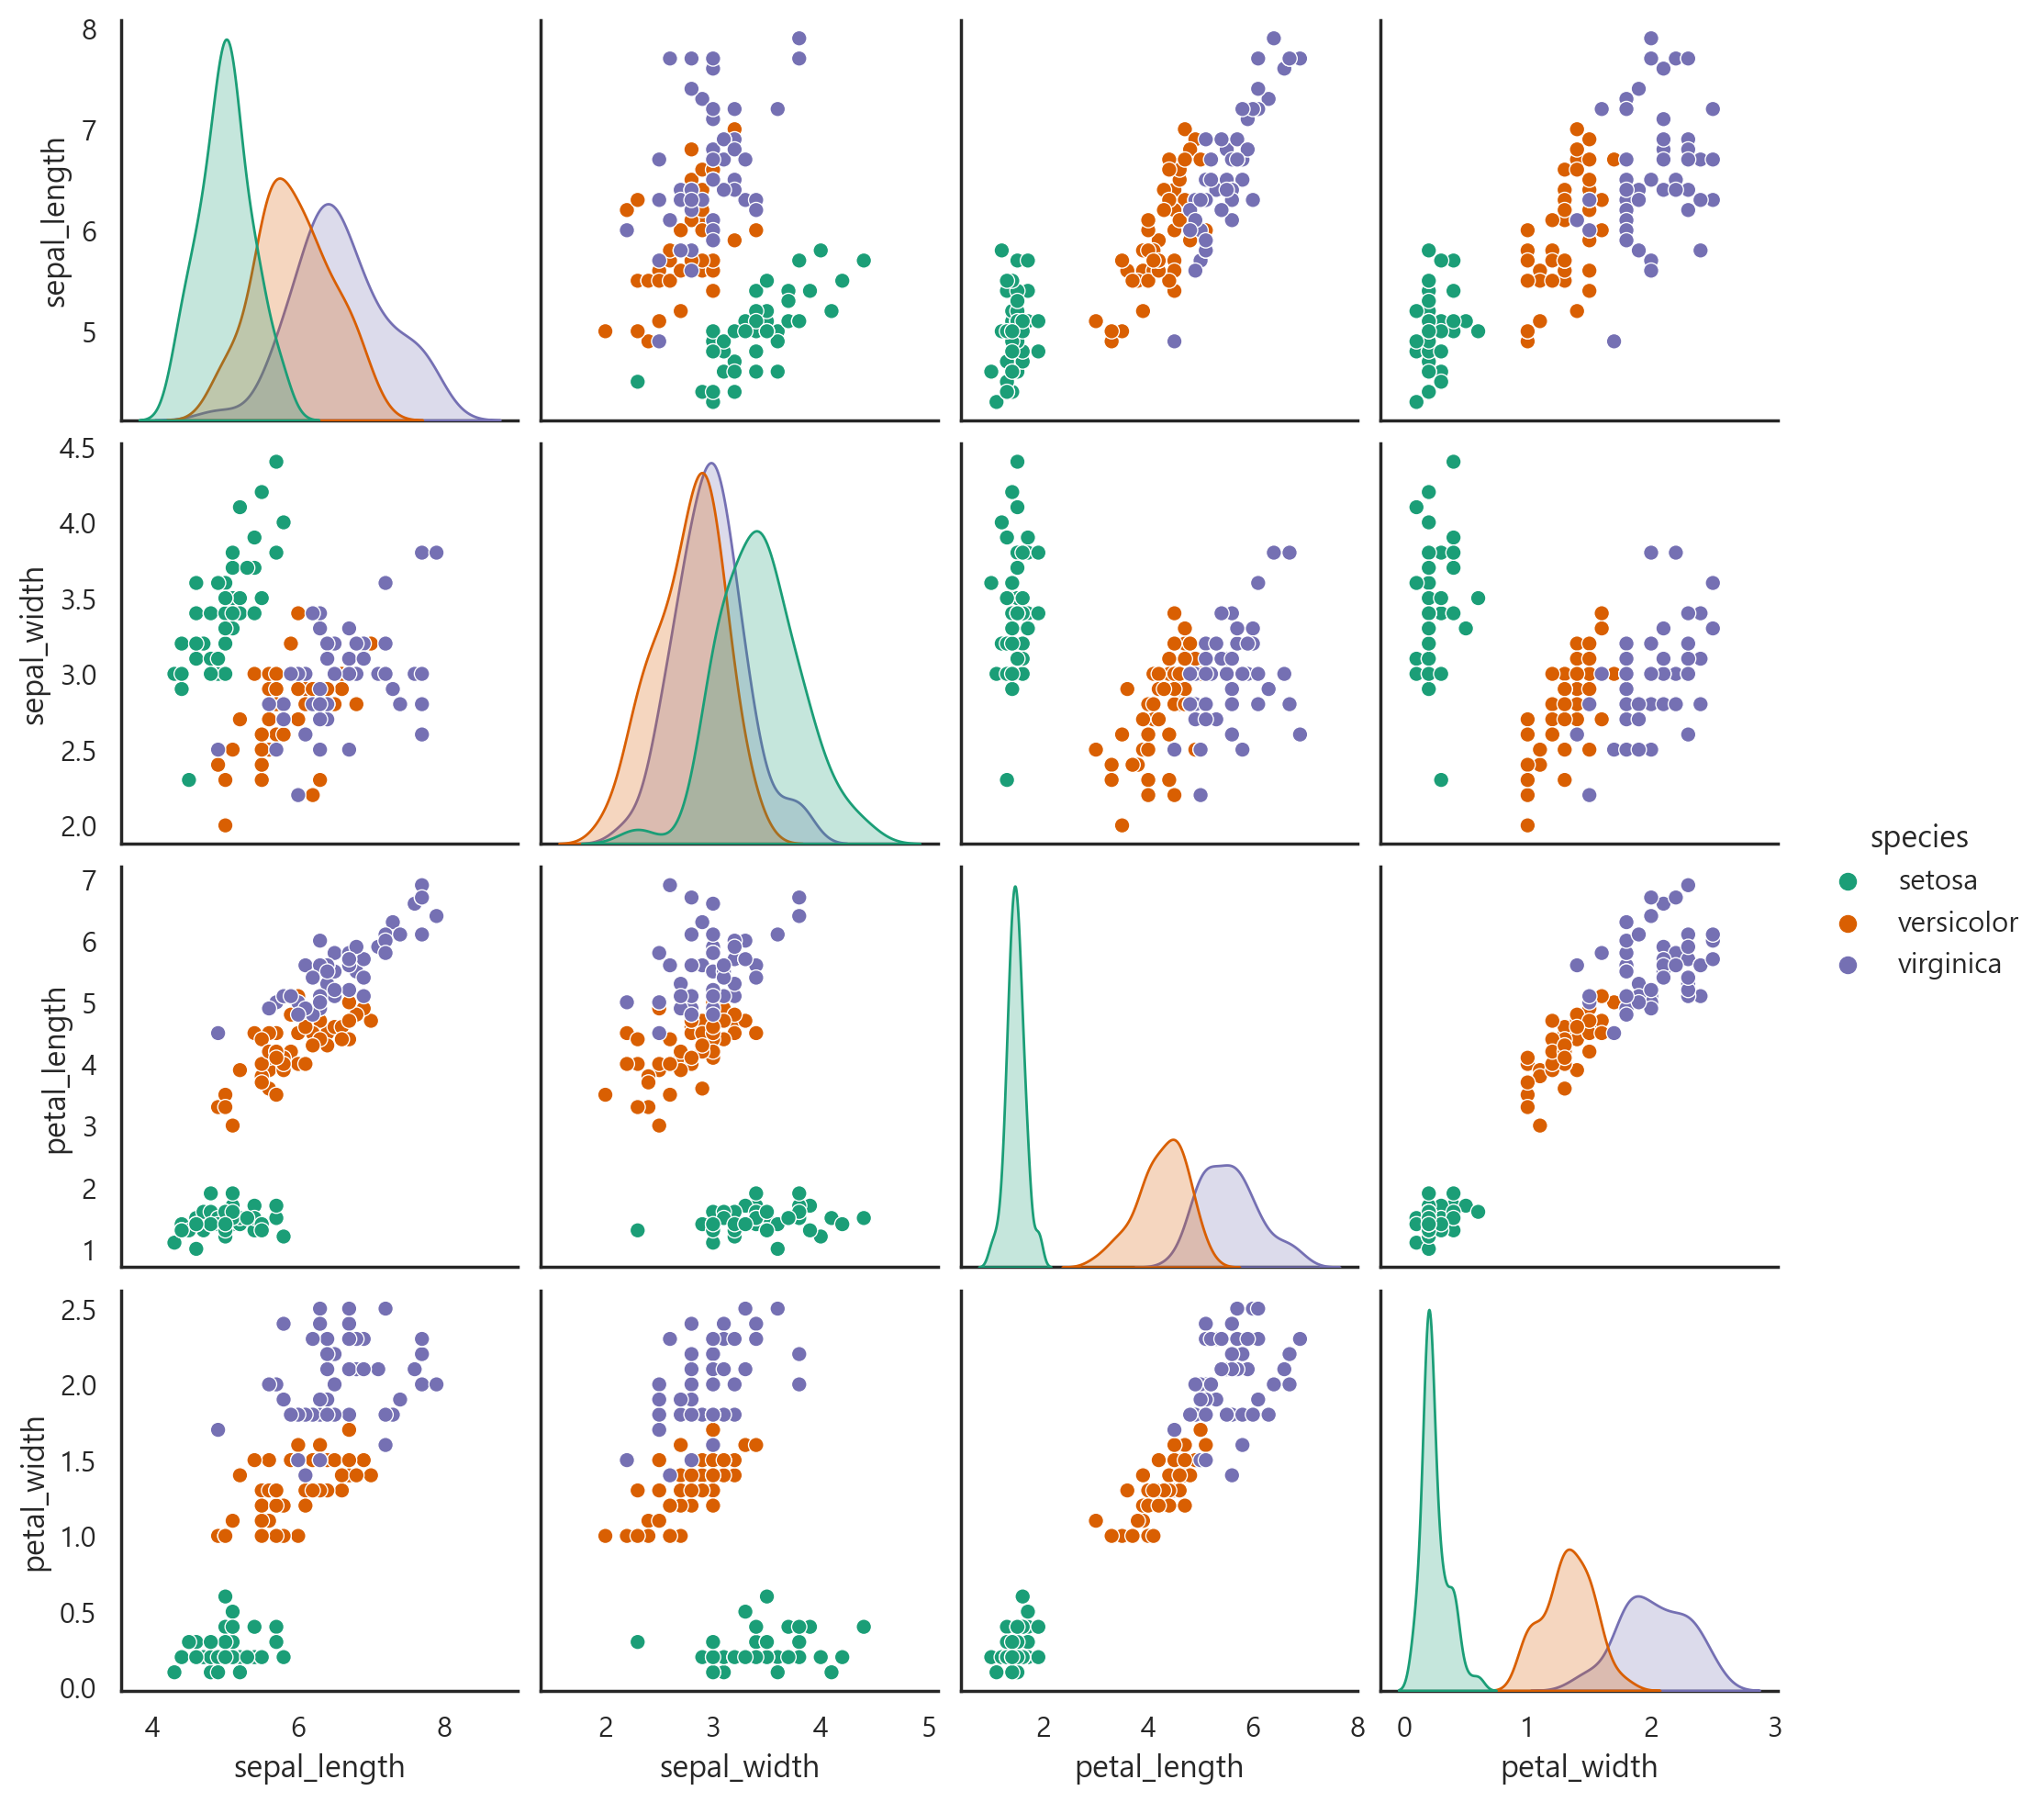

In [116]:
sns.pairplot(data=iris, hue='species')
plt.show()

### 4) 밀도그래프

In [126]:
import numpy as np
x = np.random.randn(10000) # 평균0, 표준편차1인 정규분포로 10000개 데이터 배열
x.shape

(10000,)

<Axes: ylabel='Count'>

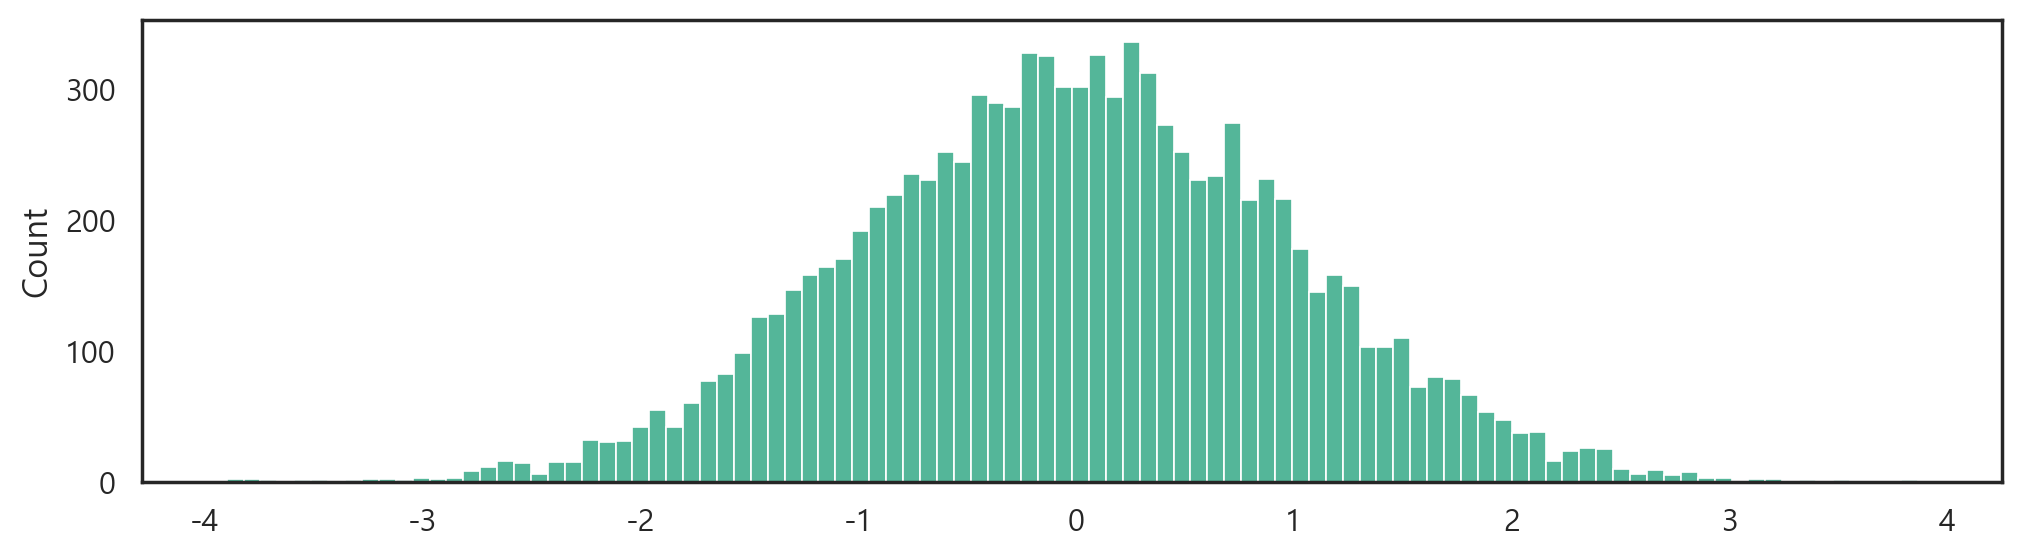

In [129]:
sns.histplot(x, bins=100)

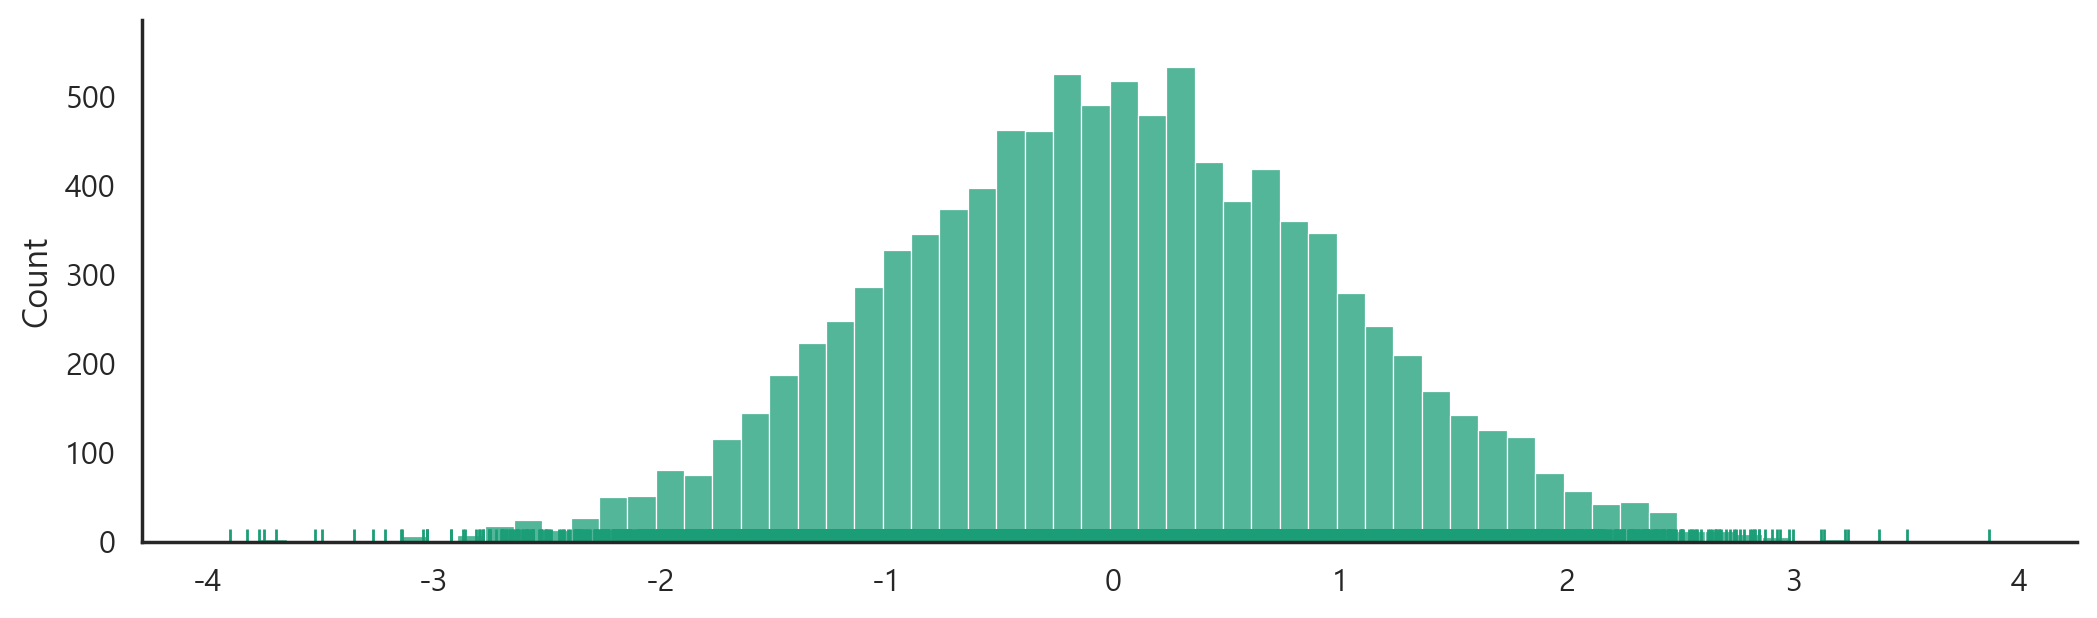

In [132]:
g = sns.displot(x, rug=True)
g.fig.set_size_inches(12, 3)

### 5) 회귀그래프
- regplot => lmplot(서브플롯)

In [133]:
corr = iris.corr(numeric_only=True)
corr = iris.iloc[:, :-1].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


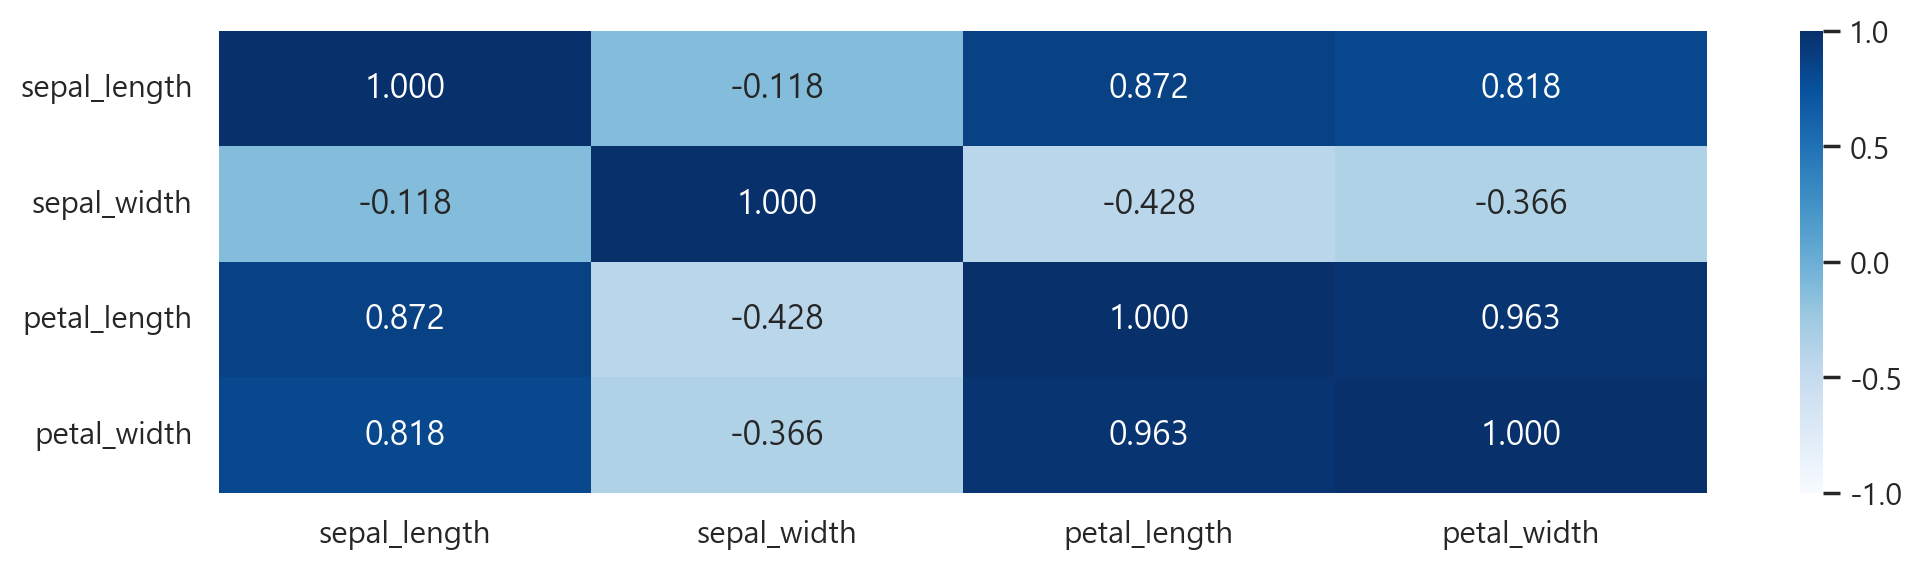

In [142]:
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt='.3f', cmap='Blues')
plt.show()

https://seaborn.pydata.org/examples/many_pairwise_correlations.html (교안 83p)

In [147]:
np.ones( (2, 2) , dtype='bool')

array([[ True,  True],
       [ True,  True]])

In [150]:
np.ones_like(corr, dtype='bool') # corr과 같은 shape의 배열(배열안 데이터 다 1)

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [154]:
# 행렬의 상삼각행렬
mask = np.triu(np.ones_like(corr, dtype=bool))
mask

array([[ True,  True,  True,  True],
       [False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True]])

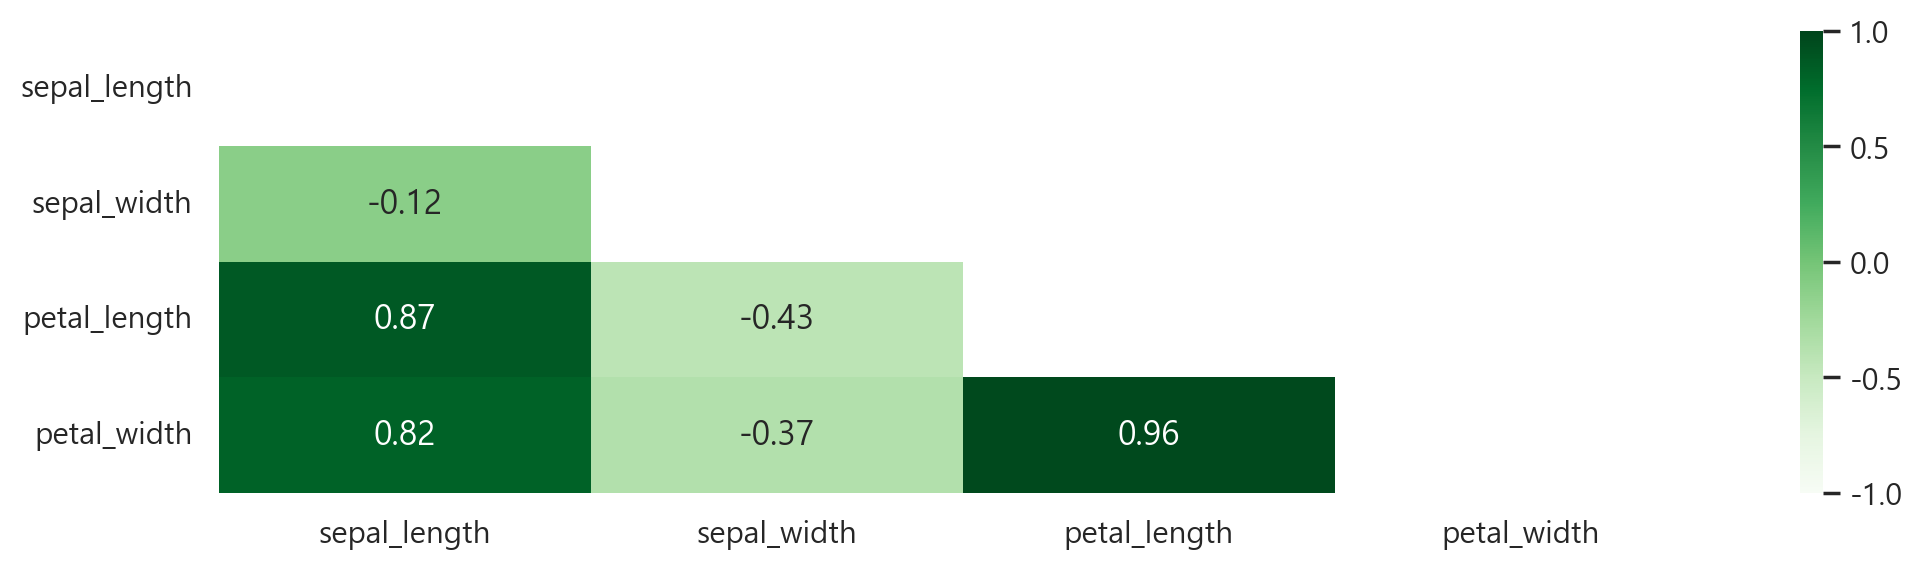

In [156]:
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, cmap='Greens', mask=mask)
plt.show()

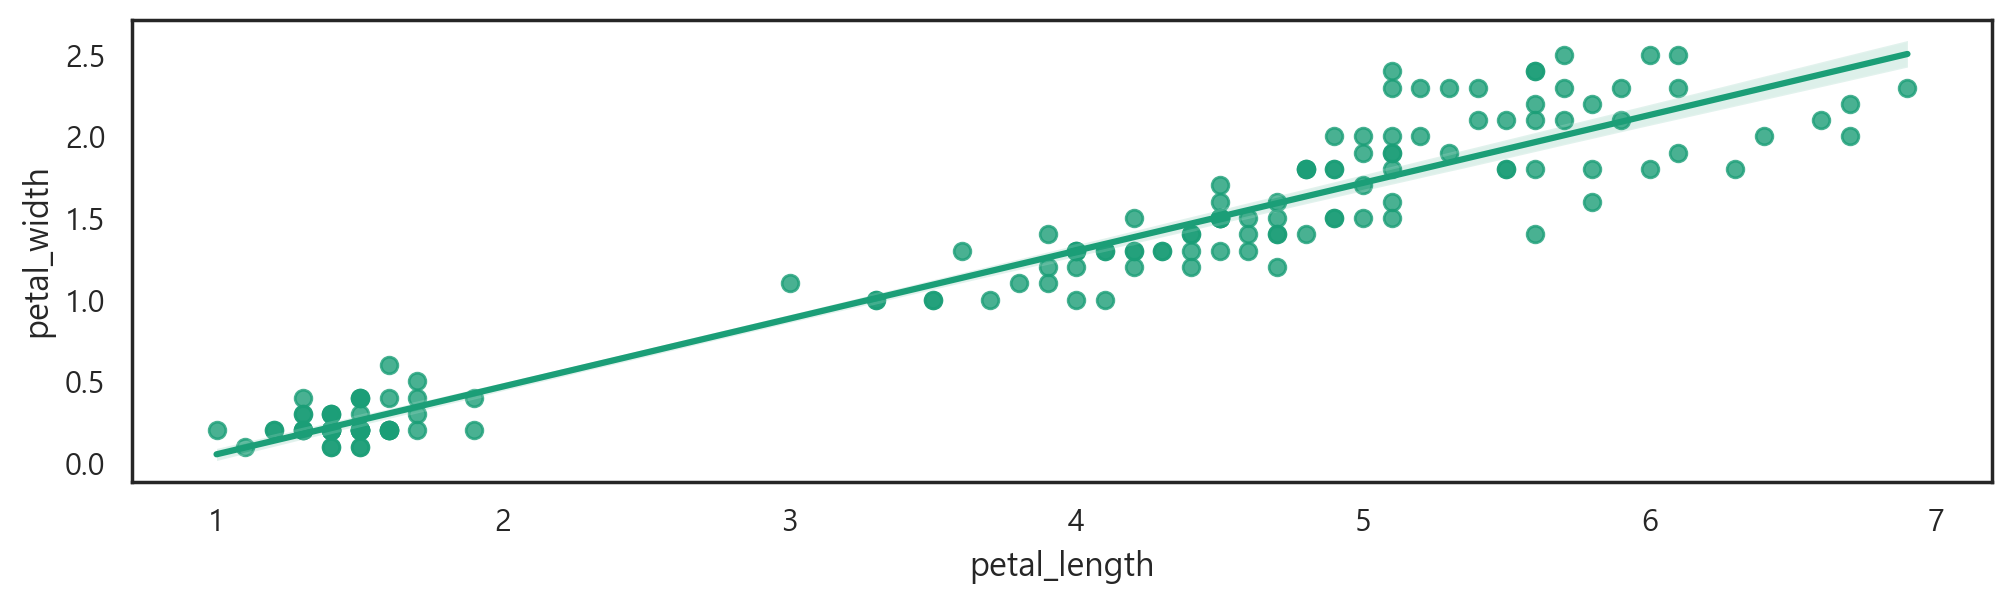

In [163]:
# 회귀그래프 : regplot(hue 사용불가), lmplot(hue사용 가능)
sns.regplot(data=iris, x='petal_length', y='petal_width')
plt.show()

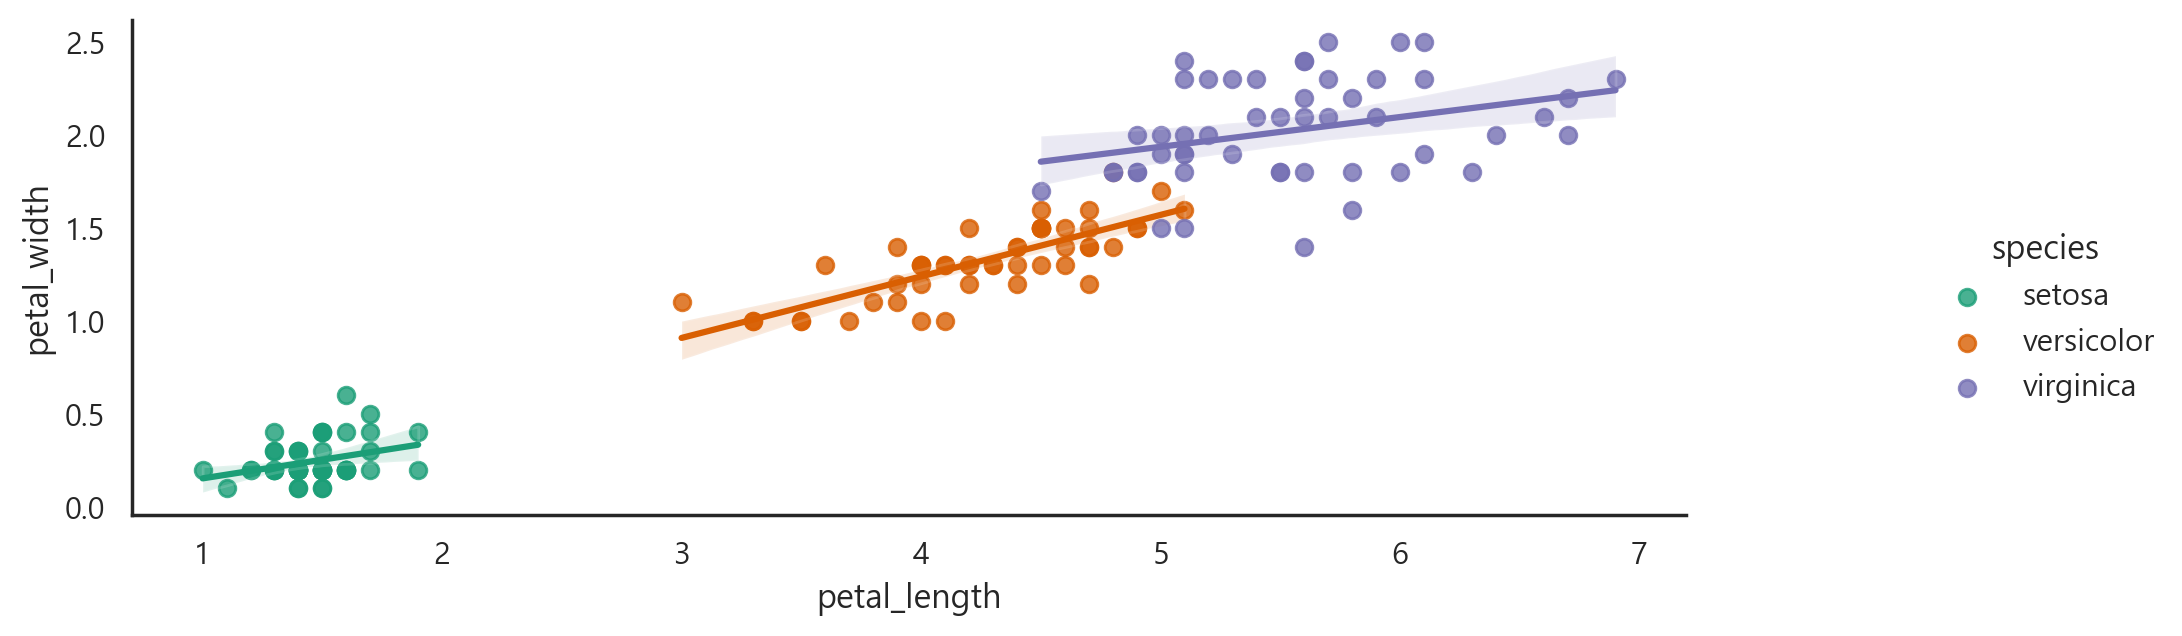

In [166]:
# species별 회귀그래프
g = sns.lmplot(data=iris, x='petal_length', y='petal_width', hue='species')
g.fig.set_size_inches(12,3)
plt.show()

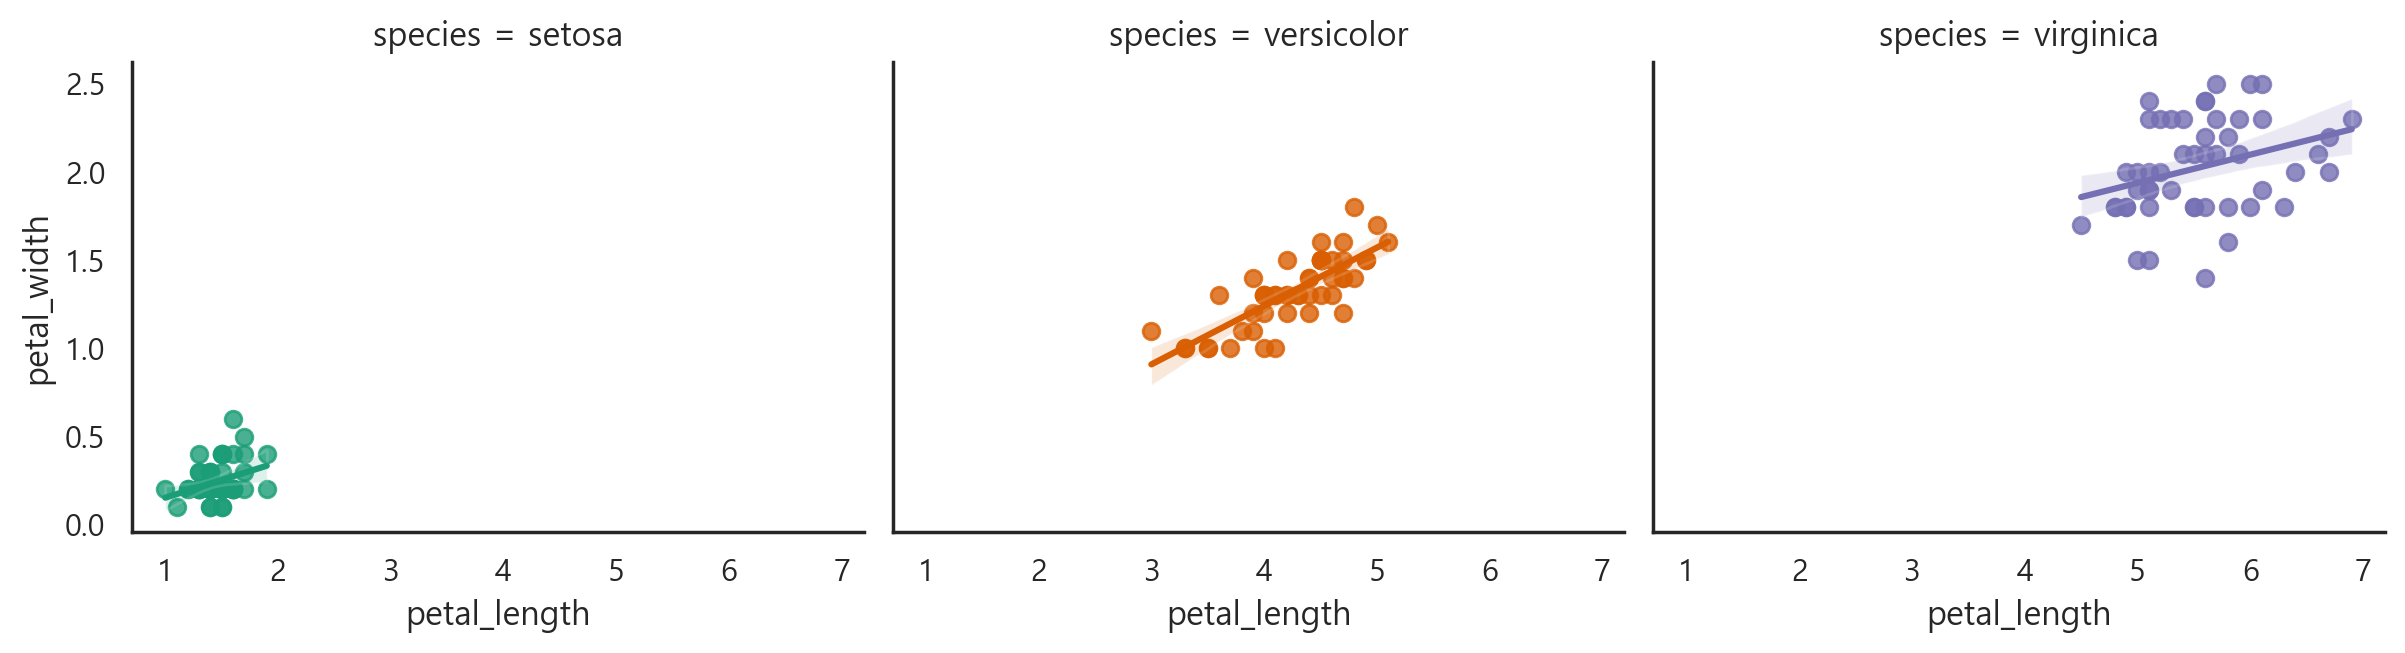

In [170]:
# species별 회귀그래프
g = sns.lmplot(data=iris, x='petal_length', y='petal_width', hue='species', 
              col='species',
              # facet_kws={'sharey':False, 'sharex':False} # 축공유 안 함
              )
g.fig.set_size_inches(12,3)
plt.show()

## 2.4 다중그래프를 위한 FacetGrid

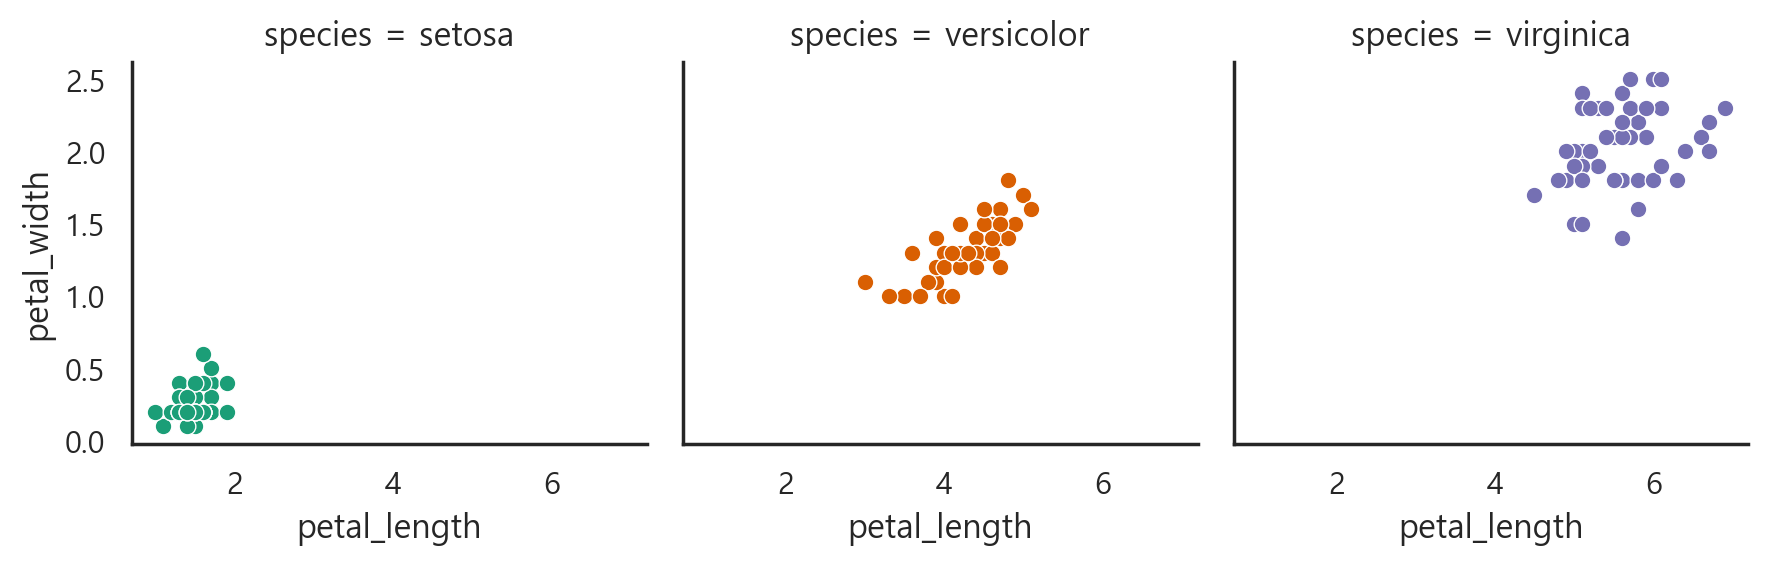

In [172]:
g = sns.FacetGrid(iris, col='species', hue='species')
g.map(sns.scatterplot, 'petal_length', 'petal_width')
plt.show()

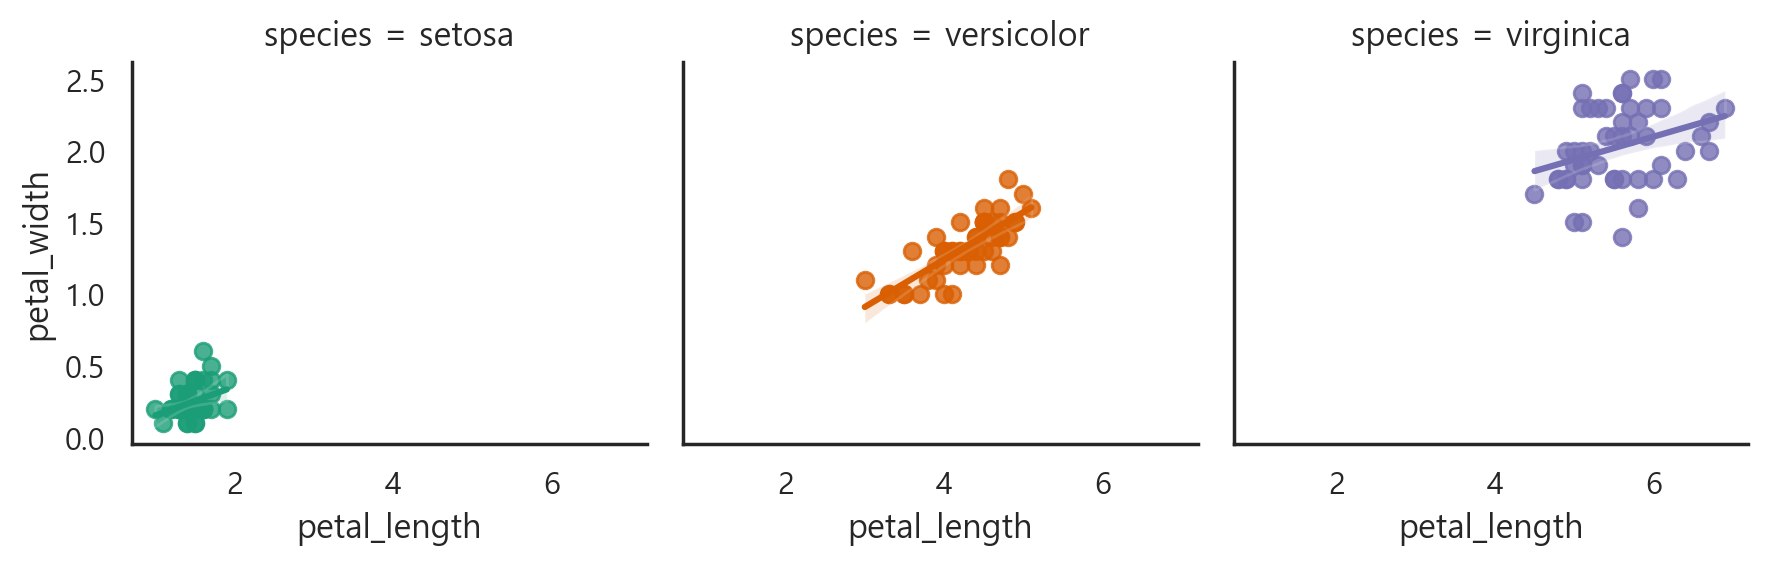

In [173]:
g = sns.FacetGrid(iris, col='species', hue='species')
g.map(sns.regplot, 'petal_length', 'petal_width')
plt.show()

In [ ]:
g = sns.FacetGrid(titanic, col='survived', hue='sex')